<a href="https://colab.research.google.com/github/raisaaajose/Raisa-EDA-Project/blob/main/Raisa_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#RAISA JOSE
#23BDS0075

# 1. Install and Load Libraries
if (!require("corrplot")) install.packages("corrplot")
library(tidyverse)
library(corrplot)

# 2. Loading the dataset
df <- read.csv("https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Auto.csv", stringsAsFactors = FALSE)

# 3. Handling Missing Data & Data Cleaning
# Check for NA values
print("Initial Missing values count per column:")
print(colSums(is.na(df)))

# Data Cleaning: Horsepower often has "?" in this dataset.
df$horsepower <- as.numeric(as.character(df$horsepower))

# Fill missing horsepower with the median value
df$horsepower[is.na(df$horsepower)] <- median(df$horsepower, na.rm = TRUE)

# Convert Origin and Cylinders to factors for better categorization and plotting
df$origin <- factor(df$origin, levels = c(1, 2, 3), labels = c("USA", "Europe", "Japan"))
df$cylinders <- as.factor(df$cylinders)

# 4. Data Transformation
# Create a new column: Weight per Horsepower
df <- df %>%
  mutate(weight_per_hp = weight / horsepower)

# Create a final clean dataframe
df_clean <- df %>% filter(!is.na(mpg))

# 5. Basic Statistical Analysis
print("Basic Statistical Summary")
print(summary(df_clean))






[1] "Initial Missing values count per column:"
         mpg    cylinders displacement   horsepower       weight acceleration 
           0            0            0            0            0            0 
        year       origin         name 
           0            0            0 
[1] "Basic Statistical Summary"
      mpg        cylinders  displacement     horsepower        weight    
 Min.   : 9.00   3:  4     Min.   : 68.0   Min.   : 46.0   Min.   :1613  
 1st Qu.:17.00   4:199     1st Qu.:105.0   1st Qu.: 75.0   1st Qu.:2225  
 Median :22.75   5:  3     Median :151.0   Median : 93.5   Median :2804  
 Mean   :23.45   6: 83     Mean   :194.4   Mean   :104.5   Mean   :2978  
 3rd Qu.:29.00   8:103     3rd Qu.:275.8   3rd Qu.:126.0   3rd Qu.:3615  
 Max.   :46.60             Max.   :455.0   Max.   :230.0   Max.   :5140  
  acceleration        year          origin           name     weight_per_hp  
 Min.   : 8.00   Min.   :70.00   USA   :245   Length   :392   Min.   :13.72  
 1st Qu.:

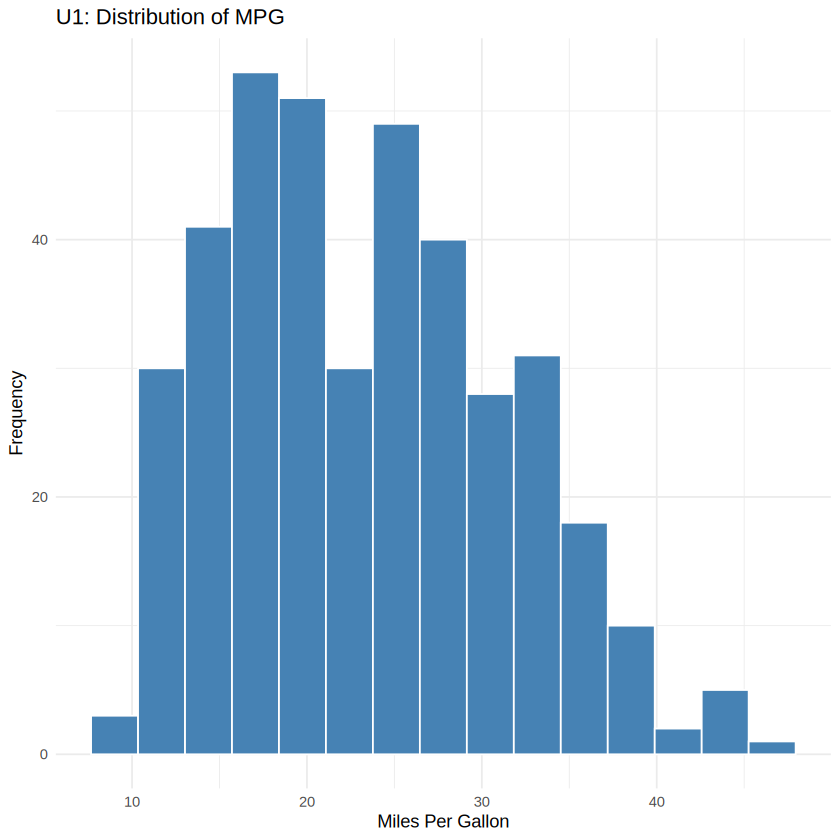

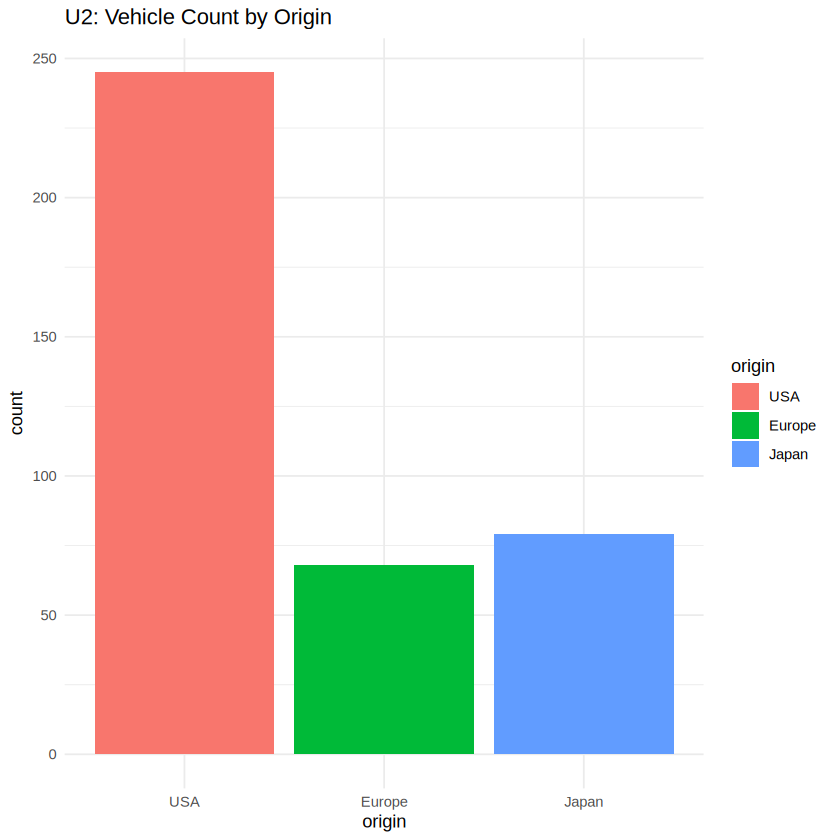

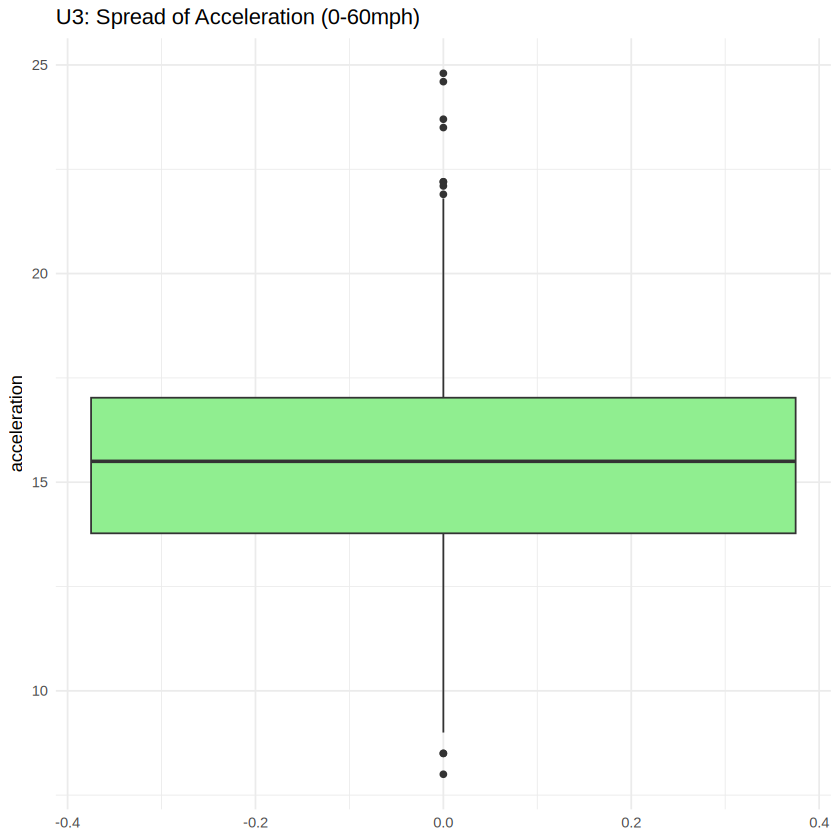

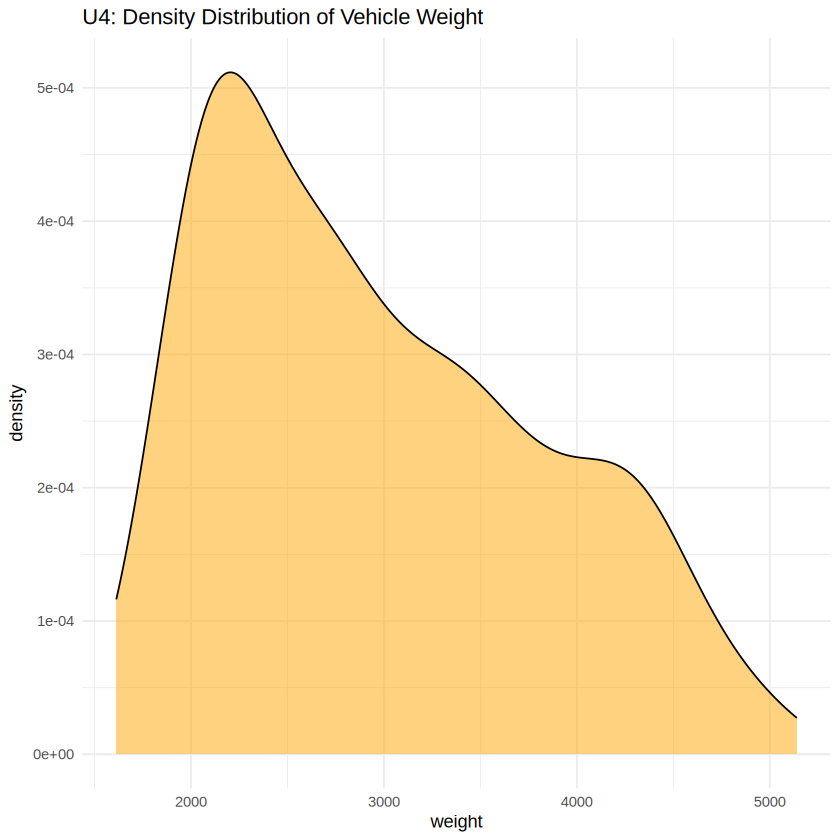

In [6]:
# 6. Univariate Analysis

# Viz 1: Histogram of MPG (Distribution)
p1 <- ggplot(df_clean, aes(x = mpg)) +
  geom_histogram(fill = "steelblue", color = "white", bins = 15) +
  theme_minimal() +
  labs(title = "U1: Distribution of MPG", x = "Miles Per Gallon", y = "Frequency")
print(p1)

# Viz 2: Count of Cars by Origin (Bar Chart)
p2 <- ggplot(df_clean, aes(x = origin, fill = origin)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "U2: Vehicle Count by Origin")
print(p2)

# Viz 3: Spread of Acceleration (Boxplot)
p3 <- ggplot(df_clean, aes(y = acceleration)) +
  geom_boxplot(fill = "lightgreen") +
  theme_minimal() +
  labs(title = "U3: Spread of Acceleration (0-60mph)")
print(p3)

# Viz 4: Density of Vehicle Weight (Density Plot)
p4 <- ggplot(df_clean, aes(x = weight)) +
  geom_density(fill = "orange", alpha = 0.5) +
  theme_minimal() +
  labs(title = "U4: Density Distribution of Vehicle Weight")
print(p4)

`geom_smooth()` using formula = 'y ~ x'


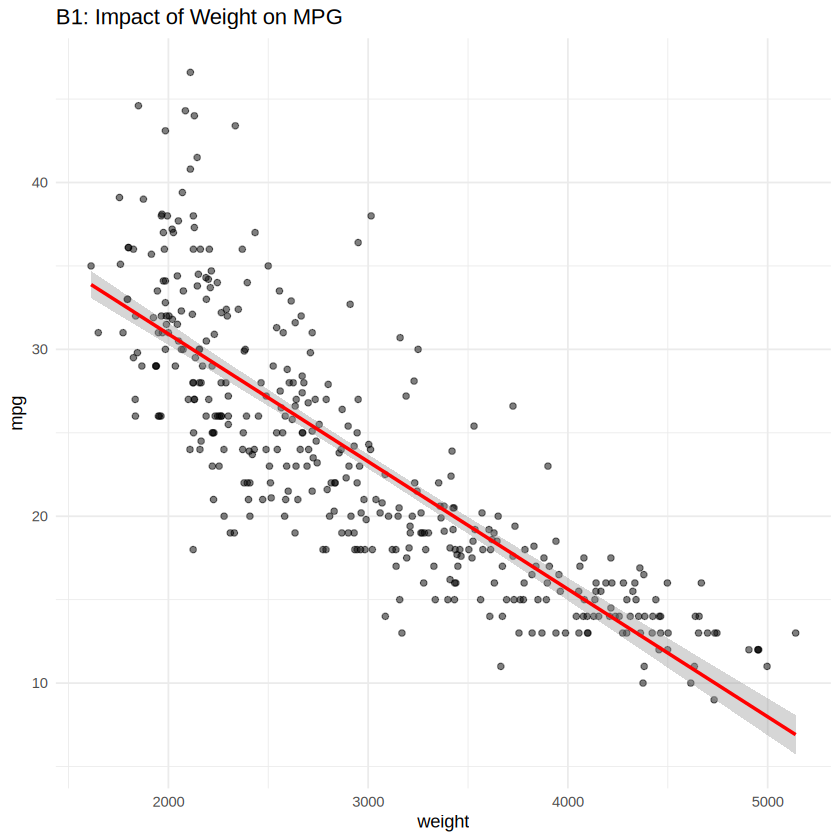

`geom_smooth()` using formula = 'y ~ x'


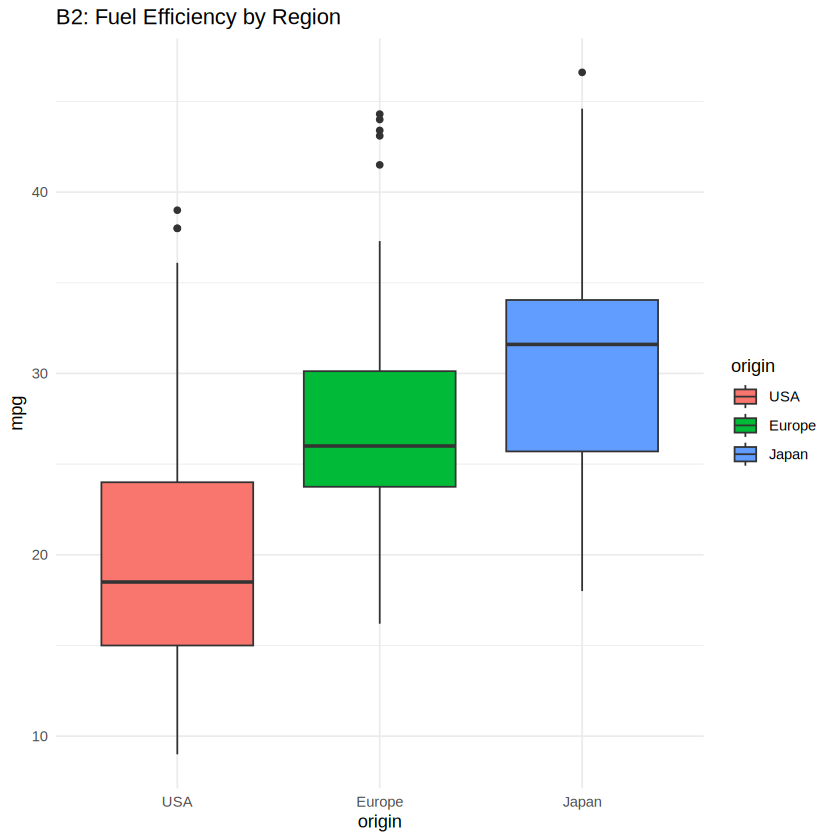

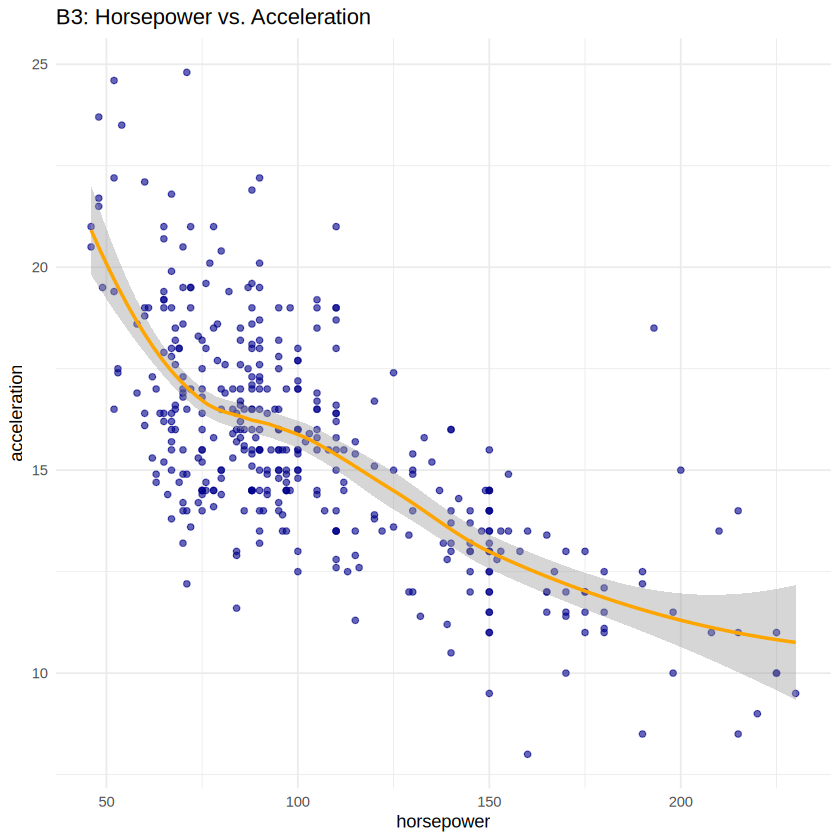

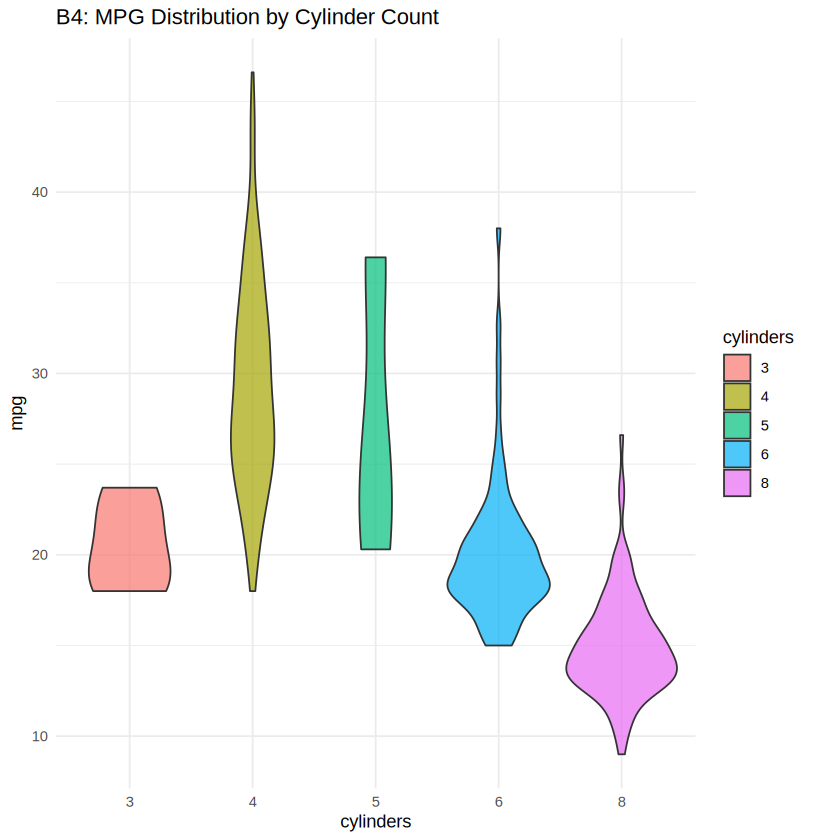

In [7]:
# 7. Bivariate Analysis

# Viz 1: MPG vs Weight (Scatter Plot + Regression Line)
p5 <- ggplot(df_clean, aes(x = weight, y = mpg)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "red") +
  theme_minimal() +
  labs(title = "B1: Impact of Weight on MPG")
print(p5)

# Viz 2: MPG by Origin (Boxplot)
p6 <- ggplot(df_clean, aes(x = origin, y = mpg, fill = origin)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "B2: Fuel Efficiency by Region")
print(p6)

# Viz 3: Horsepower vs Acceleration (Scatter Plot)
p7 <- ggplot(df_clean, aes(x = horsepower, y = acceleration)) +
  geom_point(color = "darkblue", alpha = 0.6) +
  geom_smooth(method = "loess", color = "orange") +
  theme_minimal() +
  labs(title = "B3: Horsepower vs. Acceleration")
print(p7)

# Viz 4: MPG by Cylinder Count (Violin Plot)
p8 <- ggplot(df_clean, aes(x = cylinders, y = mpg, fill = cylinders)) +
  geom_violin(alpha = 0.7) +
  theme_minimal() +
  labs(title = "B4: MPG Distribution by Cylinder Count")
print(p8)


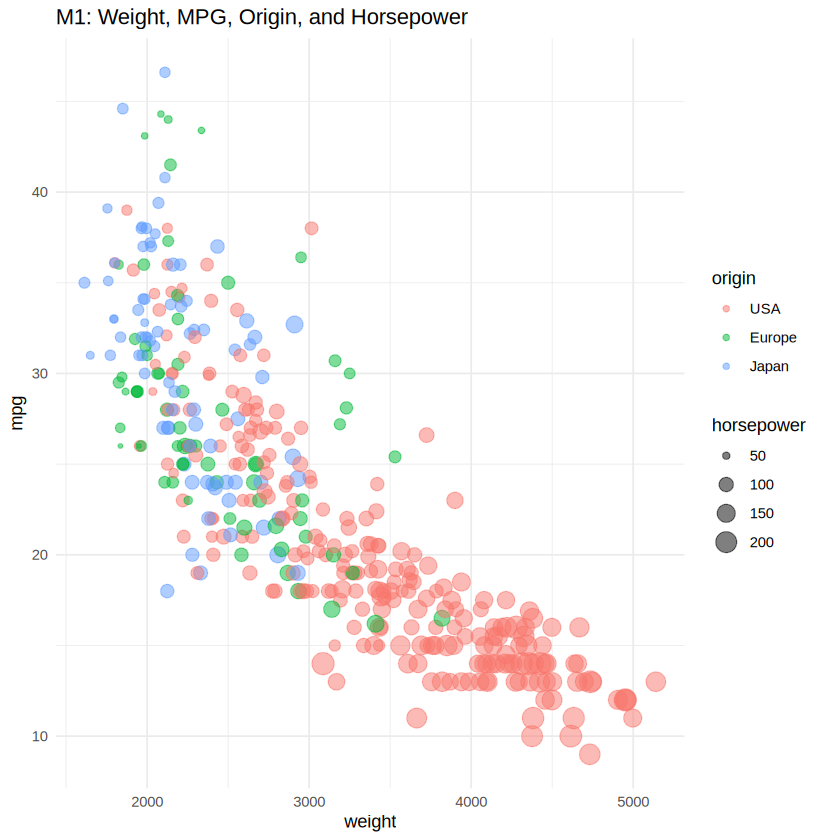

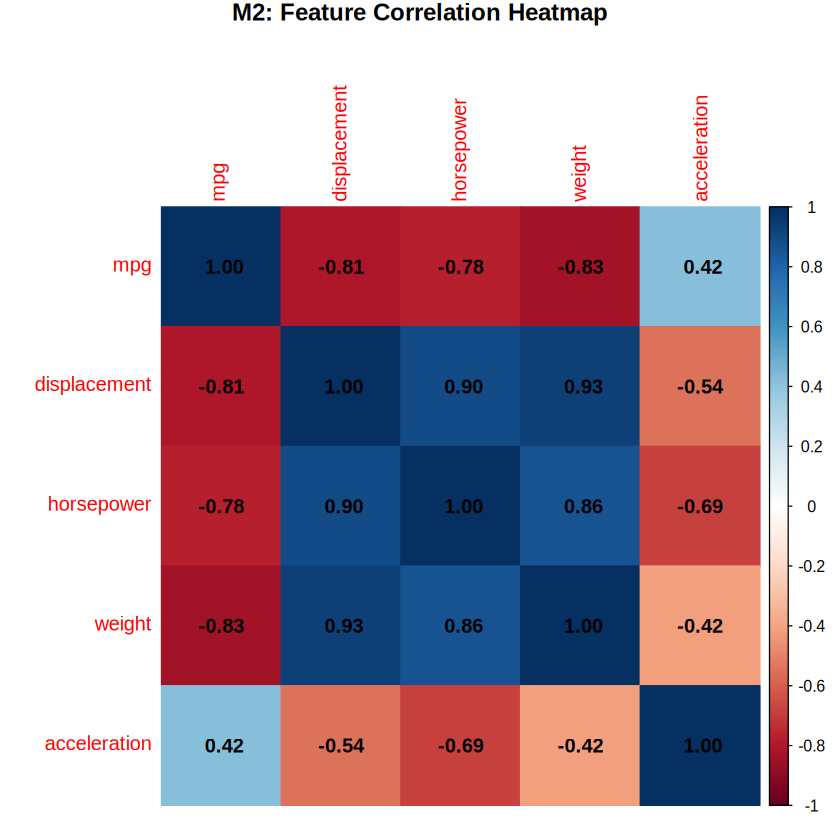

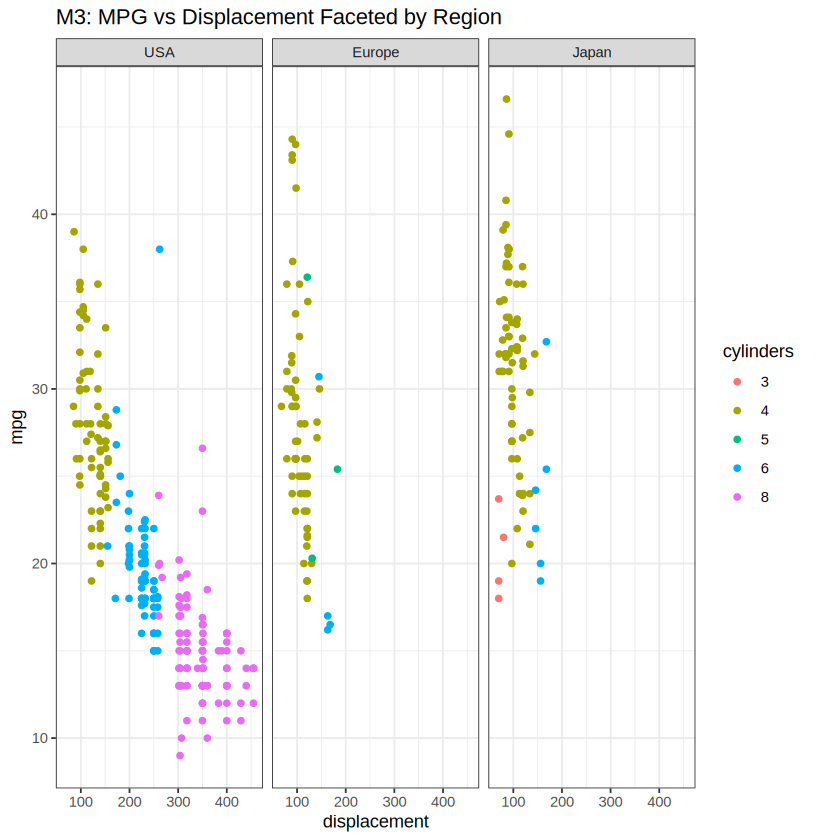

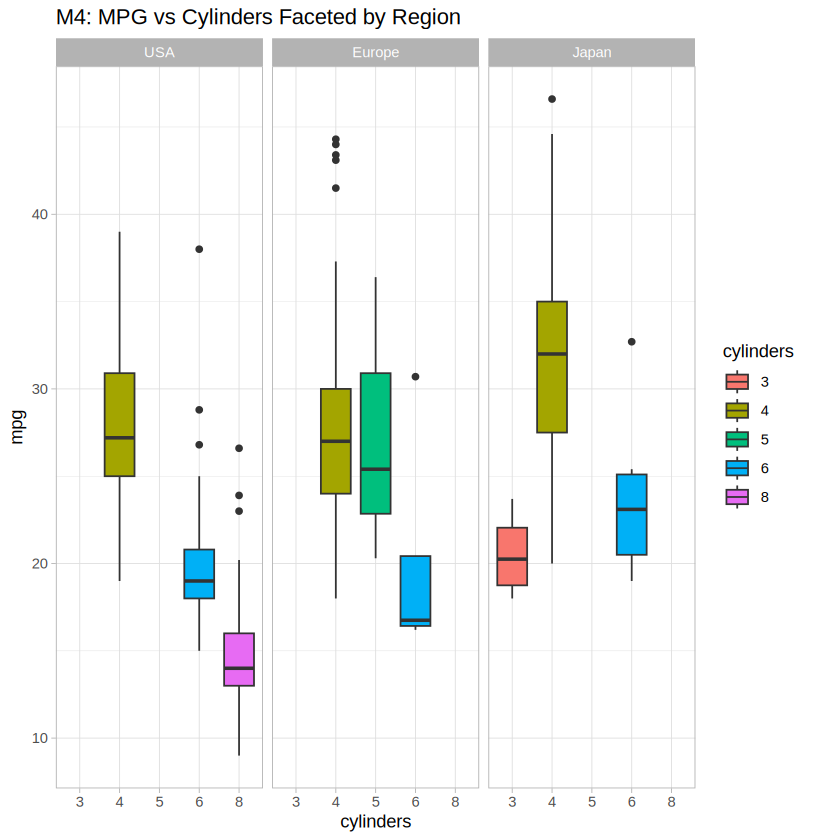

In [8]:
# 8. Multivariate Analysis

# Viz 1: Weight vs MPG colored by Origin and sized by HP
p9 <- ggplot(df_clean, aes(x = weight, y = mpg, color = origin, size = horsepower)) +
  geom_point(alpha = 0.5) +
  theme_minimal() +
  labs(title = "M1: Weight, MPG, Origin, and Horsepower")
print(p9)

# Viz 2: Correlation Heatmap (All numeric variables)
numeric_cols <- df_clean %>% select(mpg, displacement, horsepower, weight, acceleration)
cor_matrix <- cor(numeric_cols)
corrplot(cor_matrix, method = "color", addCoef.col = "black",
         title = "M2: Feature Correlation Heatmap", mar=c(0,0,1,0))

# Viz 3: Faceted Scatter Plot (MPG vs Displacement faceted by Origin)
p11 <- ggplot(df_clean, aes(x = displacement, y = mpg, color = cylinders)) +
  geom_point() +
  facet_wrap(~origin) +
  theme_bw() +
  labs(title = "M3: MPG vs Displacement Faceted by Region")
print(p11)

# Viz 4: Faceted Boxplot (MPG vs Cylinders faceted by Origin)
p12 <- ggplot(df_clean, aes(x = cylinders, y = mpg, fill = cylinders)) +
  geom_boxplot() +
  facet_wrap(~origin) +
  theme_light() +
  labs(title = "M4: MPG vs Cylinders Faceted by Region")
print(p12)


PHASE 2 - STATISTICAL ANALYSIS AND CLUSTERING

10. 1D / UNIVARIATE STATISTICAL ANALYSIS

Numerical variables used for 1D analysis:
[1] "mpg"           "displacement"  "horsepower"    "weight"       
[5] "acceleration"  "year"          "weight_per_hp"

Complete 1D Descriptive Statistics:
       Variable Count       Mean     Median   Mode    Minimum         Q1
1           mpg   392   23.44592   22.75000   13.0    9.00000   17.00000
2  displacement   392  194.41199  151.00000   97.0   68.00000  105.00000
3    horsepower   392  104.46939   93.50000  150.0   46.00000   75.00000
4        weight   392 2977.58418 2803.50000 2130.0 1613.00000 2225.25000
5  acceleration   392   15.54133   15.50000   14.5    8.00000   13.77500
6          year   392   75.97959   76.00000   73.0   70.00000   73.00000
7 weight_per_hp   392   29.52956   29.16702   25.0   13.71556   26.25928
          Q3    Maximum      Range     Variance Standard_Deviation         IQR
1   29.00000   46.60000   37.60000 6.091814e+01 

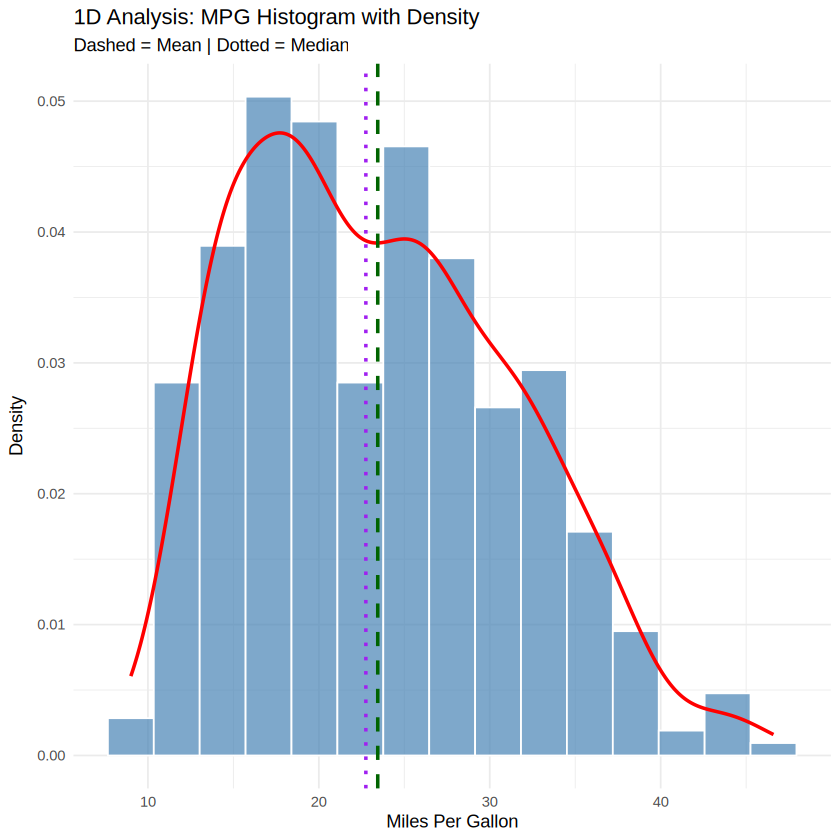

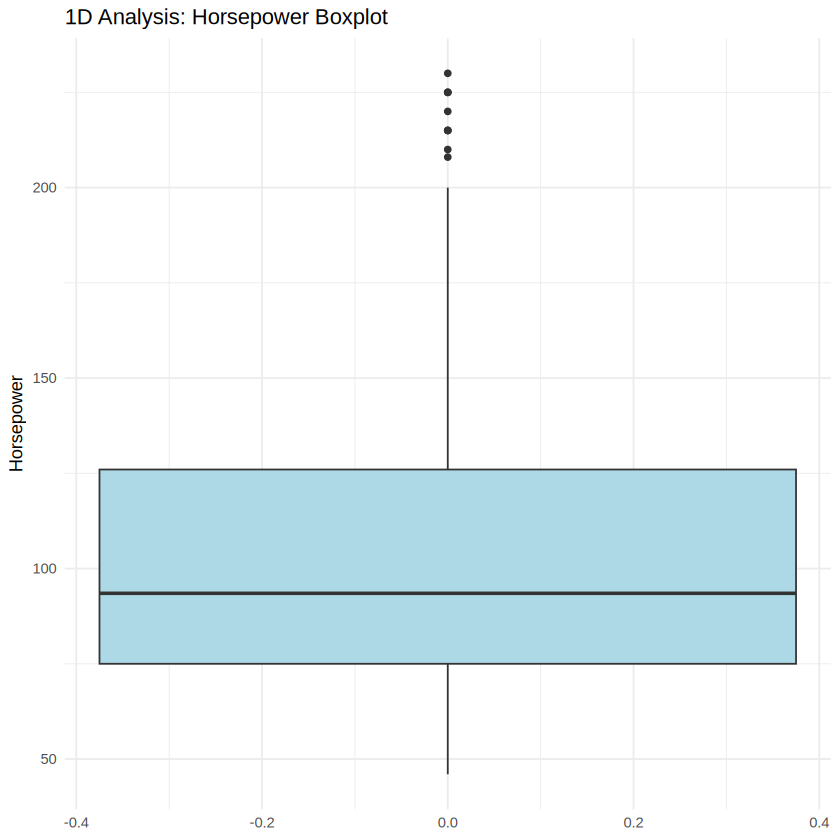


IQR Outlier Summary:
                   Variable Number_of_IQR_Outliers
mpg                     mpg                      0
displacement   displacement                      0
horsepower       horsepower                     10
weight               weight                      0
acceleration   acceleration                     11
year                   year                      0
weight_per_hp weight_per_hp                     12

11. 2D / BIVARIATE STATISTICAL ANALYSIS

Covariance Matrix:
                   mpg displacement horsepower    weight acceleration    year
mpg              60.92      -657.59    -233.86  -5517.44         9.12   16.69
displacement   -657.59     10950.37    3614.03  82929.10      -156.99 -142.57
horsepower     -233.86      3614.03    1481.57  28265.62       -73.19  -59.04
weight        -5517.44     82929.10   28265.62 721484.71      -976.82 -967.23
acceleration      9.12      -156.99     -73.19   -976.82         7.61    2.95
year             16.69      -142.57     -

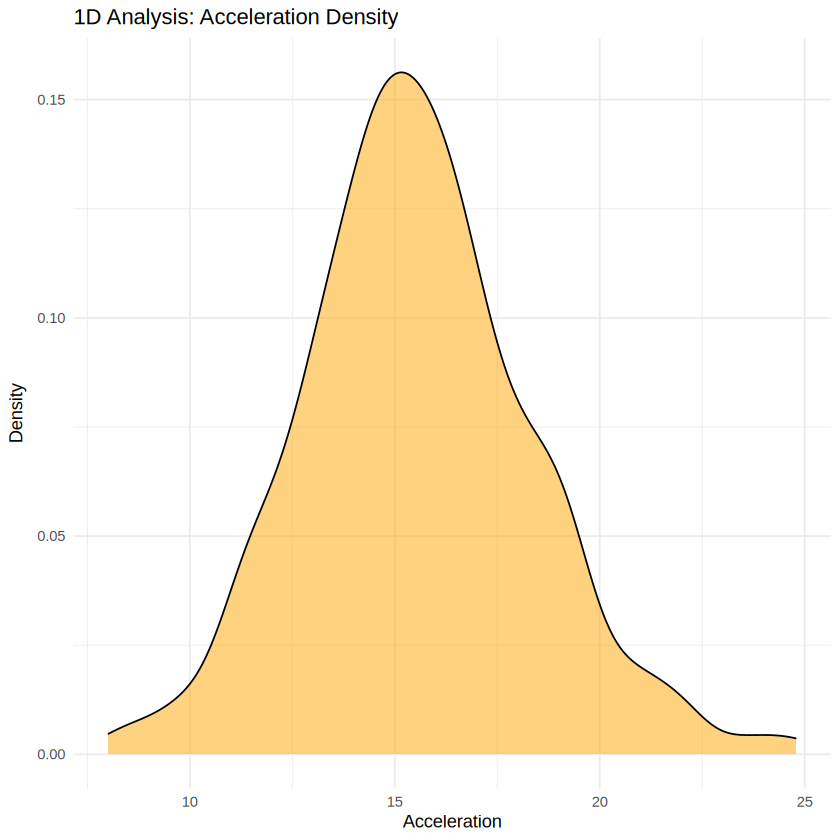


Spearman Correlation Matrix:
                 mpg displacement horsepower weight acceleration   year
mpg            1.000       -0.855     -0.854 -0.876        0.442  0.575
displacement  -0.855        1.000      0.876  0.946       -0.499 -0.307
horsepower    -0.854        0.876      1.000  0.879       -0.658 -0.389
weight        -0.876        0.946      0.879  1.000       -0.405 -0.281
acceleration   0.442       -0.499     -0.658 -0.405        1.000  0.278
year           0.575       -0.307     -0.389 -0.281        0.278  1.000
weight_per_hp  0.234       -0.181     -0.509 -0.091        0.712  0.325
              weight_per_hp
mpg                   0.234
displacement         -0.181
horsepower           -0.509
weight               -0.091
acceleration          0.712
year                  0.325
weight_per_hp         1.000

Pearson Correlation Test: MPG vs Weight

	Pearson's product-moment correlation

data:  df_phase2$mpg and df_phase2$weight
t = -29.645, df = 390, p-value < 2.2e-16
altern

`geom_smooth()` using formula = 'y ~ x'


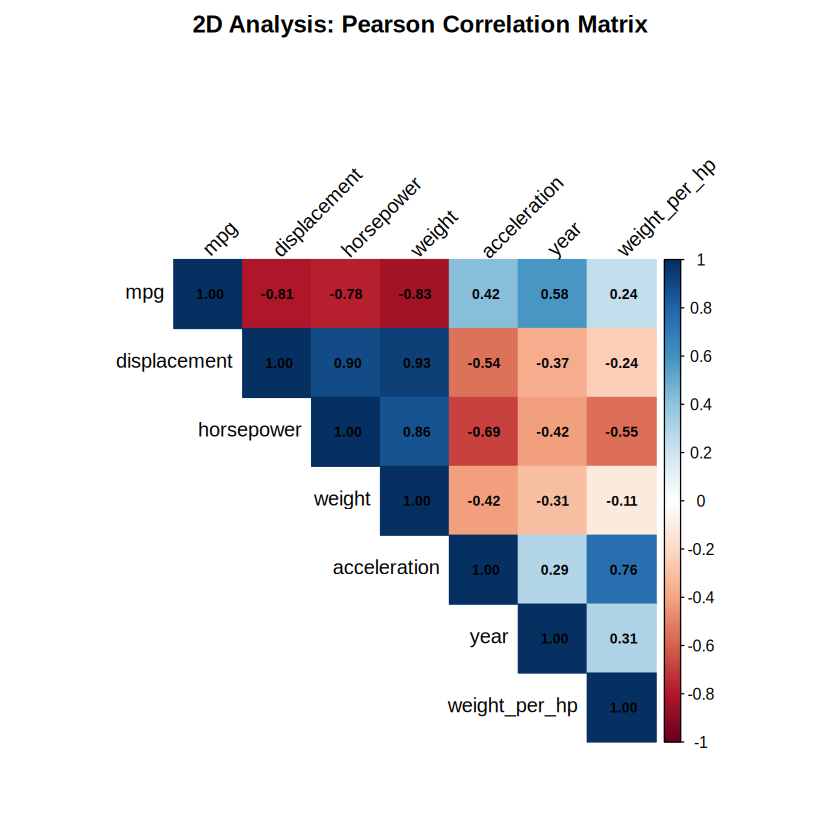


Simple Linear Regression: MPG ~ Weight

Call:
lm(formula = mpg ~ weight, data = df_phase2)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.9736  -2.7556  -0.3358   2.1379  16.5194 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 46.216524   0.798673   57.87   <2e-16 ***
weight      -0.007647   0.000258  -29.64   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.333 on 390 degrees of freedom
Multiple R-squared:  0.6926,	Adjusted R-squared:  0.6918 
F-statistic: 878.8 on 1 and 390 DF,  p-value: < 2.2e-16



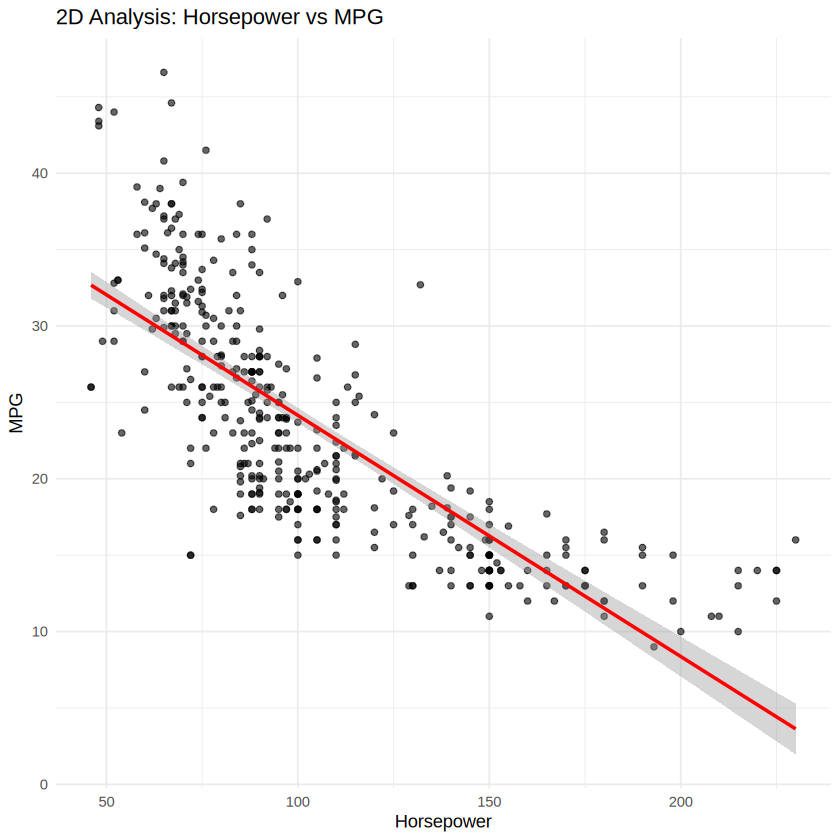


MPG Statistics by Origin:
# A tibble: 3 × 7
  origin Count Mean_MPG Median_MPG SD_MPG Min_MPG Max_MPG
  <fct>  <int>    <dbl>      <dbl>  <dbl>   <dbl>   <dbl>
1 USA      245     20.0       18.5   6.44     9      39  
2 Europe    68     27.6       26     6.58    16.2    44.3
3 Japan     79     30.5       31.6   6.09    18      46.6

MPG Statistics by Cylinder Count:
# A tibble: 5 × 5
  cylinders Count Mean_MPG Median_MPG SD_MPG
  <fct>     <int>    <dbl>      <dbl>  <dbl>
1 3             4     20.6       20.2   2.56
2 4           199     29.3       28.4   5.67
3 5             3     27.4       25.4   8.23
4 6            83     20.0       19     3.83
5 8           103     15.0       14     2.84

Two-Way Frequency Table: Origin x Cylinders
        
           3   4   5   6   8
  USA      0  69   0  73 103
  Europe   0  61   3   4   0
  Japan    4  69   0   6   0

Row Percentages:
        
             3     4     5     6     8
  USA     0.00 28.16  0.00 29.80 42.04
  Europe  0.00 89.71  

Warning message in chisq.test(origin_cylinder_table):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  origin_cylinder_table
X-squared = 180.72, df = 8, p-value < 2.2e-16


One-Way ANOVA: MPG by Origin
             Df Sum Sq Mean Sq F value Pr(>F)    
origin        2   7904    3952    96.6 <2e-16 ***
Residuals   389  15915      41                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Tukey HSD Post-Hoc Test:
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = mpg ~ origin, data = df_phase2)

$origin
                  diff       lwr       upr     p adj
Europe-USA    7.569472 5.5068042  9.632139 0.0000000
Japan-USA    10.417164 8.4701431 12.364184 0.0000000
Japan-Europe  2.847692 0.3583458  5.337038 0.0202502



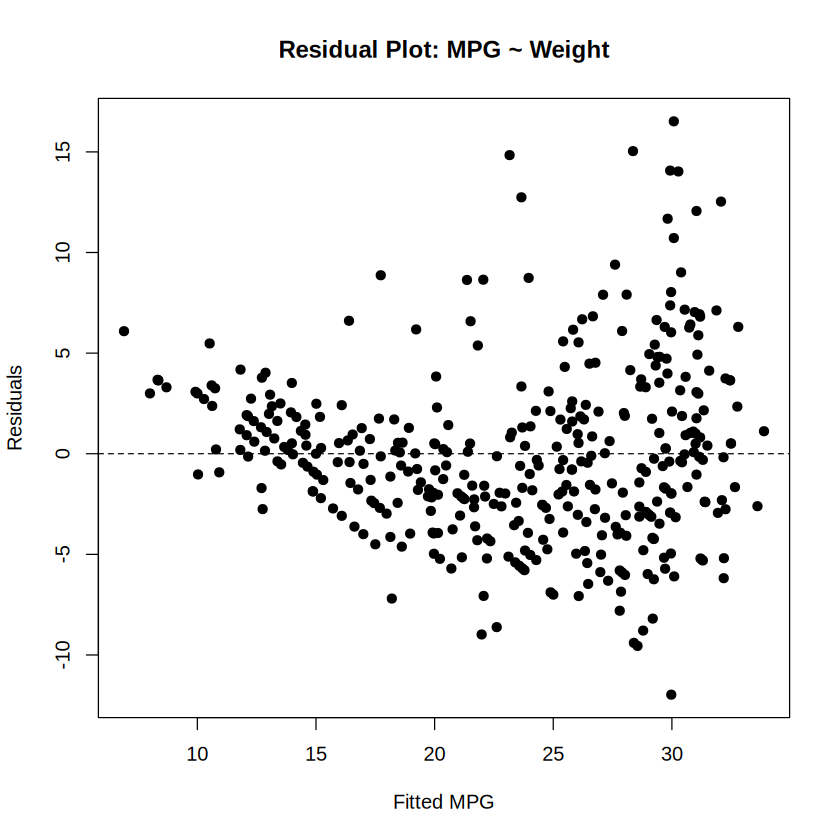

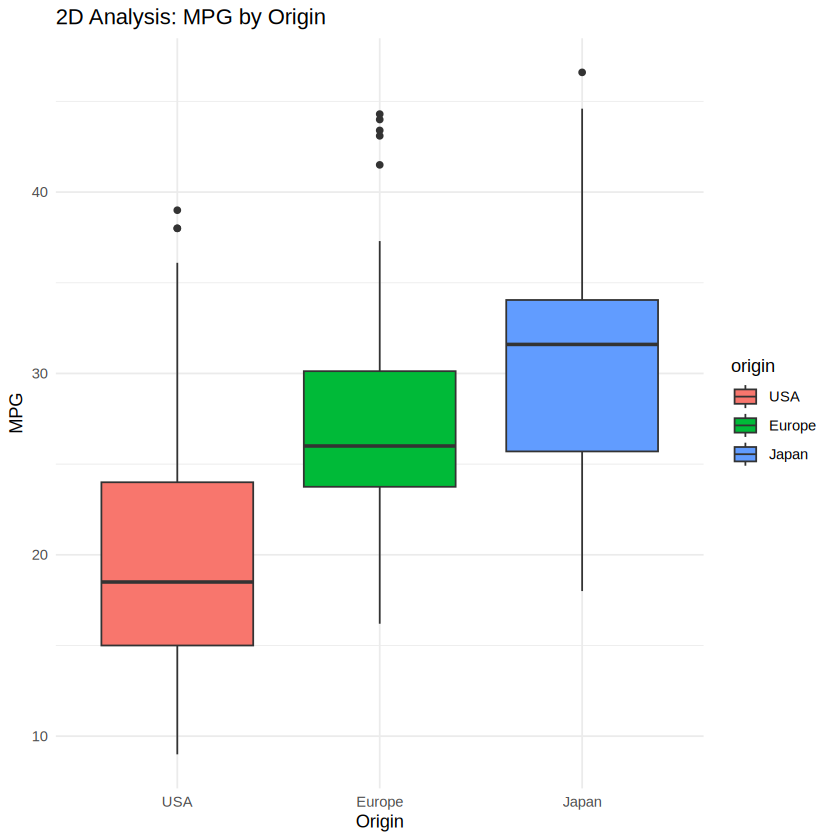


12. 3D / THREE-VARIABLE STATISTICAL ANALYSIS

3D Summary: Origin + Cylinders + MPG
# A tibble: 9 × 8
  origin cylinders Count Mean_MPG Median_MPG SD_MPG Mean_Horsepower Mean_Weight
  <fct>  <fct>     <int>    <dbl>      <dbl>  <dbl>           <dbl>       <dbl>
1 USA    4            69     28.0       27.2   4.57            81.0       2427.
2 USA    6            73     19.6       19     3.39            99.7       3219.
3 USA    8           103     15.0       14     2.84           158.        4115.
4 Europe 4            61     28.1       27     6.29            78.3       2338.
5 Europe 5             3     27.4       25.4   8.23            82.3       3103.
6 Europe 6             4     20.1       16.8   7.07           114.        3382.
7 Japan  3             4     20.6       20.2   2.56            99.2       2398.
8 Japan  4            69     31.6       32     5.44            75.6       2153.
9 Japan  6             6     23.9       23.1   4.95           116.        2882 


`geom_smooth()` using formula = 'y ~ x'


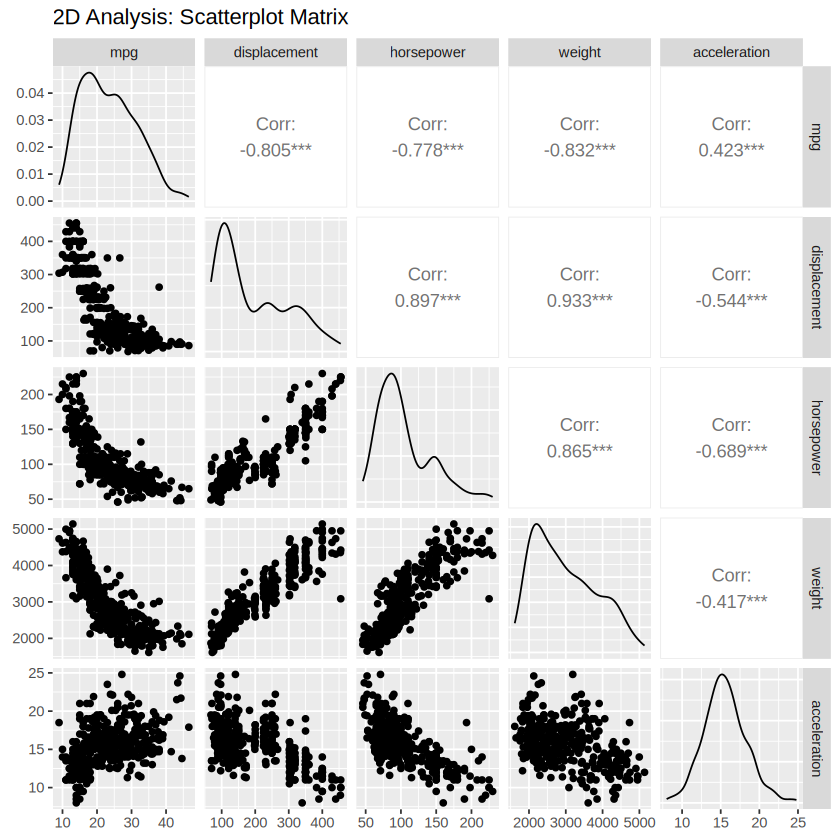

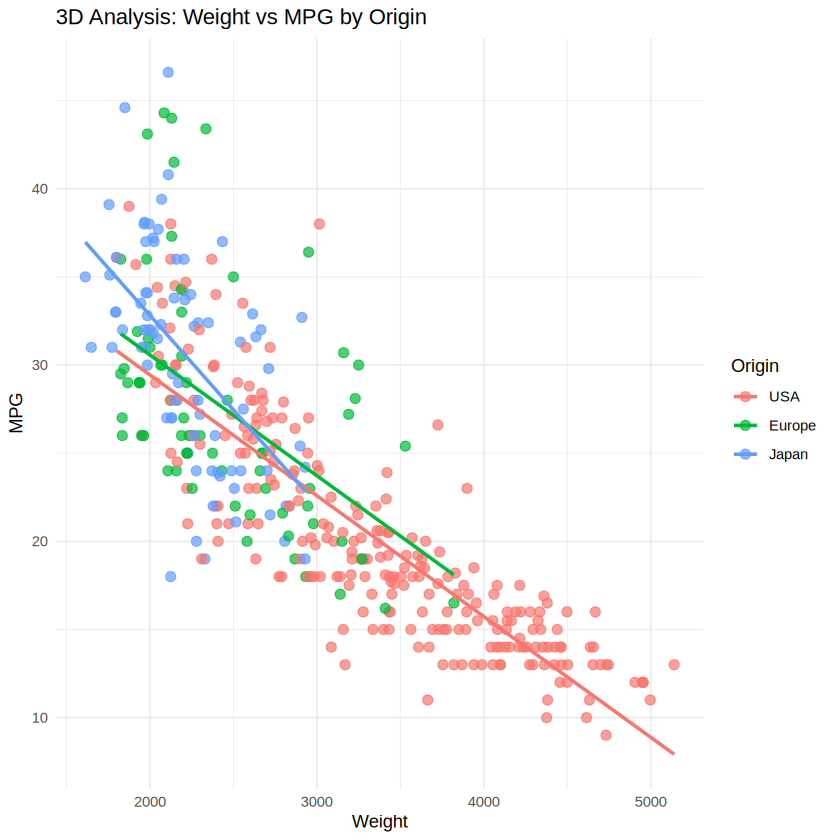

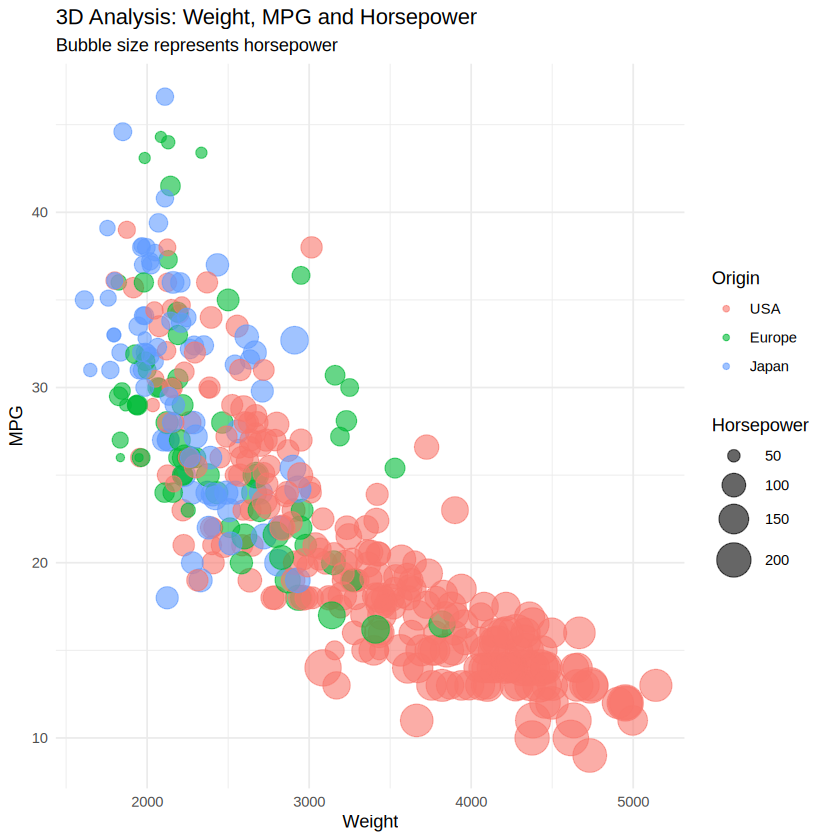

`geom_smooth()` using formula = 'y ~ x'


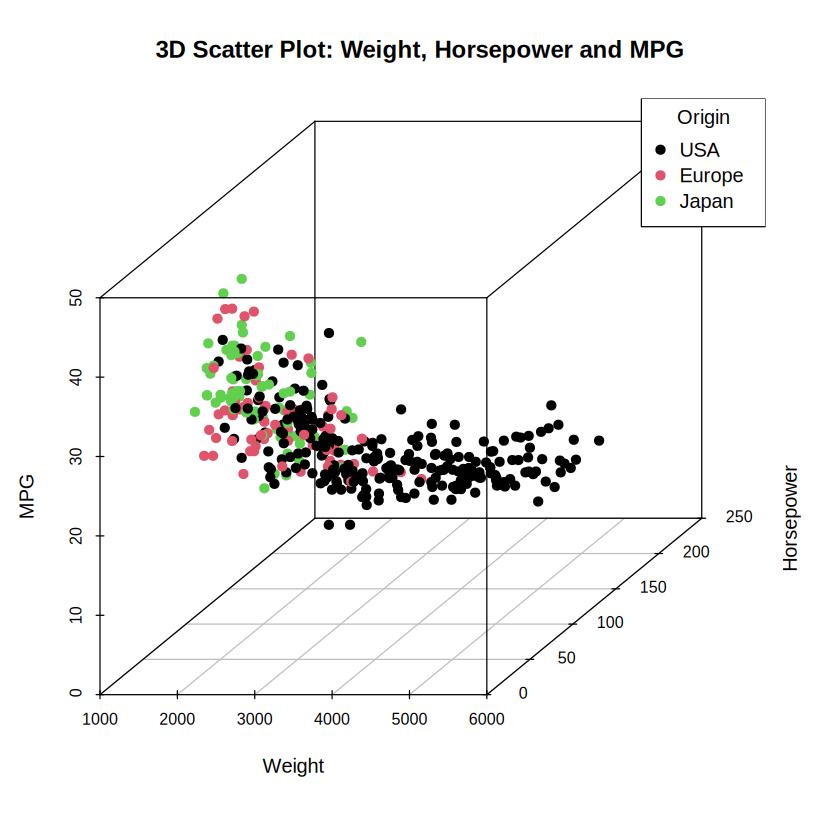


Multiple Linear Regression: MPG ~ Weight + Horsepower

Call:
lm(formula = mpg ~ weight + horsepower, data = df_phase2)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.0762  -2.7340  -0.3312   2.1752  16.2601 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 45.6402108  0.7931958  57.540  < 2e-16 ***
weight      -0.0057942  0.0005023 -11.535  < 2e-16 ***
horsepower  -0.0473029  0.0110851  -4.267 2.49e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.24 on 389 degrees of freedom
Multiple R-squared:  0.7064,	Adjusted R-squared:  0.7049 
F-statistic: 467.9 on 2 and 389 DF,  p-value: < 2.2e-16


Extended Multiple Linear Regression Model:

Call:
lm(formula = mpg ~ displacement + horsepower + weight + acceleration + 
    year + origin, data = df_phase2)

Residuals:
   Min     1Q Median     3Q    Max 
-8.729 -2.115 -0.021  1.923 13.292 

Coefficients:
               Estimate Std. Error t value 

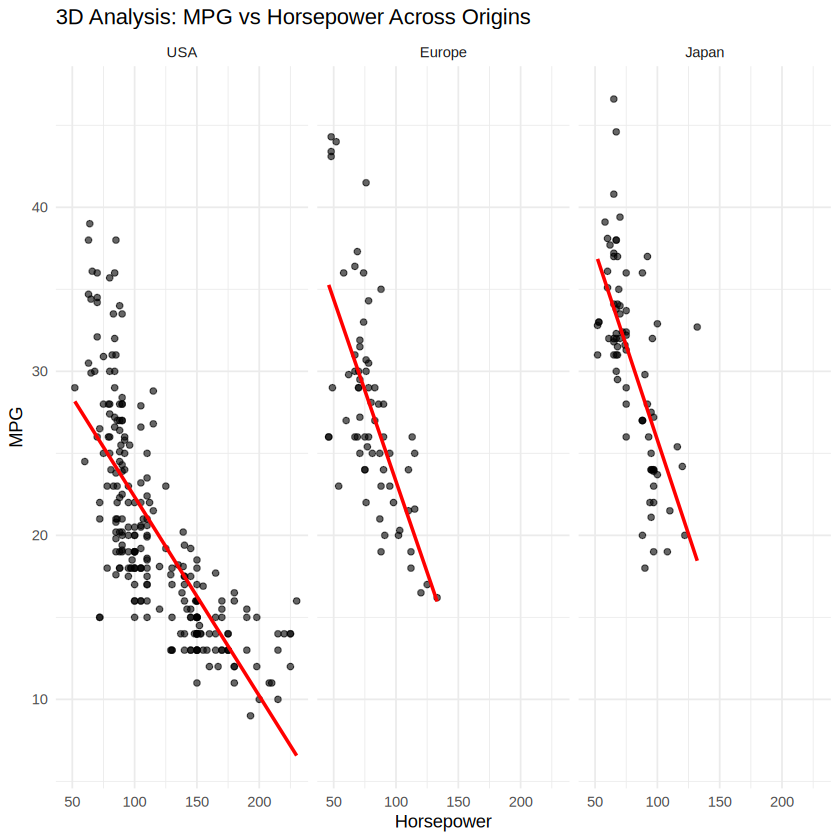

In [10]:
# ================================================================
# PHASE 2
# ALL 1D, 2D AND 3D STATISTICAL ANALYSES
# K-MEANS AND HIERARCHICAL CLUSTERING
# ================================================================

# ------------------------------------------------
# 9. INSTALL AND LOAD ADDITIONAL LIBRARIES
# ------------------------------------------------

if (!require("e1071")) install.packages("e1071")
if (!require("GGally")) install.packages("GGally")
if (!require("scatterplot3d")) install.packages("scatterplot3d")

library(e1071)
library(GGally)
library(scatterplot3d)
library(cluster)

# Work on a separate copy so Phase 1 data is not modified
df_phase2 <- df_clean

cat("\n============================================================\n")
cat("PHASE 2 - STATISTICAL ANALYSIS AND CLUSTERING\n")
cat("============================================================\n")


# ================================================================
# 10. 1D STATISTICAL ANALYSIS
# ================================================================
# 1D / Univariate analysis studies one variable at a time.

cat("\n============================================================\n")
cat("10. 1D / UNIVARIATE STATISTICAL ANALYSIS\n")
cat("============================================================\n")


# ------------------------------------------------
# 10.1 Numerical Variables
# ------------------------------------------------

numeric_1d <- df_phase2 %>%
  select(
    mpg,
    displacement,
    horsepower,
    weight,
    acceleration,
    year,
    weight_per_hp
  )

cat("\nNumerical variables used for 1D analysis:\n")
print(names(numeric_1d))


# ------------------------------------------------
# 10.2 Complete Descriptive Statistics
# ------------------------------------------------

one_d_statistics <- data.frame(
  Variable = names(numeric_1d),

  Count = sapply(numeric_1d, function(x)
    sum(!is.na(x))),

  Mean = sapply(numeric_1d, mean, na.rm = TRUE),

  Median = sapply(numeric_1d, median, na.rm = TRUE),

  Mode = sapply(
    numeric_1d,
    function(x) {
      ux <- unique(x)
      ux[which.max(tabulate(match(x, ux)))]
    }
  ),

  Minimum = sapply(numeric_1d, min, na.rm = TRUE),

  Q1 = sapply(
    numeric_1d,
    function(x) quantile(x, 0.25, na.rm = TRUE)
  ),

  Q3 = sapply(
    numeric_1d,
    function(x) quantile(x, 0.75, na.rm = TRUE)
  ),

  Maximum = sapply(numeric_1d, max, na.rm = TRUE),

  Range = sapply(
    numeric_1d,
    function(x)
      diff(range(x, na.rm = TRUE))
  ),

  Variance = sapply(numeric_1d, var, na.rm = TRUE),

  Standard_Deviation = sapply(numeric_1d, sd, na.rm = TRUE),

  IQR = sapply(numeric_1d, IQR, na.rm = TRUE),

  Skewness = sapply(
    numeric_1d,
    function(x)
      e1071::skewness(x, na.rm = TRUE, type = 2)
  ),

  Kurtosis = sapply(
    numeric_1d,
    function(x)
      e1071::kurtosis(x, na.rm = TRUE, type = 2)
  )
)

rownames(one_d_statistics) <- NULL

cat("\nComplete 1D Descriptive Statistics:\n")
print(one_d_statistics)


# ------------------------------------------------
# 10.3 Coefficient of Variation
# ------------------------------------------------
# CV helps compare variability among variables measured
# on different scales.

coefficient_of_variation <- data.frame(
  Variable = names(numeric_1d),

  CV_Percentage = sapply(
    numeric_1d,
    function(x)
      (sd(x, na.rm = TRUE) /
         mean(x, na.rm = TRUE)) * 100
  )
)

cat("\nCoefficient of Variation (%):\n")
print(coefficient_of_variation)


# ------------------------------------------------
# 10.4 Quantiles / Percentiles
# ------------------------------------------------

quantile_table <- t(
  sapply(
    numeric_1d,
    function(x)
      quantile(
        x,
        probs = c(
          0,
          0.10,
          0.25,
          0.50,
          0.75,
          0.90,
          1
        ),
        na.rm = TRUE
      )
  )
)

cat("\nQuantiles of Numerical Variables:\n")
print(quantile_table)


# ------------------------------------------------
# 10.5 Frequency Distribution - Origin
# ------------------------------------------------

origin_frequency <- table(df_phase2$origin)
origin_relative_frequency <- prop.table(origin_frequency)
origin_percentage <- origin_relative_frequency * 100

cat("\nFrequency Distribution of Origin:\n")
print(origin_frequency)

cat("\nRelative Frequency of Origin:\n")
print(origin_relative_frequency)

cat("\nPercentage Distribution of Origin:\n")
print(origin_percentage)


# ------------------------------------------------
# 10.6 Frequency Distribution - Cylinders
# ------------------------------------------------

cylinder_frequency <- table(df_phase2$cylinders)
cylinder_relative_frequency <- prop.table(cylinder_frequency)
cylinder_percentage <- cylinder_relative_frequency * 100

cat("\nFrequency Distribution of Cylinders:\n")
print(cylinder_frequency)

cat("\nRelative Frequency of Cylinders:\n")
print(cylinder_relative_frequency)

cat("\nPercentage Distribution of Cylinders:\n")
print(cylinder_percentage)


# ------------------------------------------------
# 10.7 Histogram + Density Curve
# ------------------------------------------------

p13 <- ggplot(
  df_phase2,
  aes(x = mpg)
) +
  geom_histogram(
    aes(y = after_stat(density)),
    bins = 15,
    fill = "steelblue",
    color = "white",
    alpha = 0.7
  ) +
  geom_density(
    color = "red",
    linewidth = 1
  ) +
  geom_vline(
    aes(xintercept = mean(mpg)),
    color = "darkgreen",
    linetype = "dashed",
    linewidth = 1
  ) +
  geom_vline(
    aes(xintercept = median(mpg)),
    color = "purple",
    linetype = "dotted",
    linewidth = 1
  ) +
  theme_minimal() +
  labs(
    title = "1D Analysis: MPG Histogram with Density",
    subtitle = "Dashed = Mean | Dotted = Median",
    x = "Miles Per Gallon",
    y = "Density"
  )

print(p13)


# ------------------------------------------------
# 10.8 Boxplot of Horsepower
# ------------------------------------------------

p14 <- ggplot(
  df_phase2,
  aes(y = horsepower)
) +
  geom_boxplot(
    fill = "lightblue"
  ) +
  theme_minimal() +
  labs(
    title = "1D Analysis: Horsepower Boxplot",
    y = "Horsepower"
  )

print(p14)


# ------------------------------------------------
# 10.9 Individual Density Plot
# ------------------------------------------------

p15 <- ggplot(
  df_phase2,
  aes(x = acceleration)
) +
  geom_density(
    fill = "orange",
    alpha = 0.5
  ) +
  theme_minimal() +
  labs(
    title = "1D Analysis: Acceleration Density",
    x = "Acceleration",
    y = "Density"
  )

print(p15)


# ------------------------------------------------
# 10.10 IQR Outlier Counts for all Numerical Variables
# ------------------------------------------------

count_iqr_outliers <- function(x) {

  q1 <- quantile(x, 0.25, na.rm = TRUE)
  q3 <- quantile(x, 0.75, na.rm = TRUE)

  iqr_value <- IQR(x, na.rm = TRUE)

  lower <- q1 - 1.5 * iqr_value
  upper <- q3 + 1.5 * iqr_value

  sum(
    x < lower | x > upper,
    na.rm = TRUE
  )
}

outlier_summary <- data.frame(
  Variable = names(numeric_1d),
  Number_of_IQR_Outliers =
    sapply(
      numeric_1d,
      count_iqr_outliers
    )
)

cat("\nIQR Outlier Summary:\n")
print(outlier_summary)


# ================================================================
# 11. 2D STATISTICAL ANALYSIS
# ================================================================
# 2D / Bivariate analysis studies relationships between
# two variables.

cat("\n============================================================\n")
cat("11. 2D / BIVARIATE STATISTICAL ANALYSIS\n")
cat("============================================================\n")


# ------------------------------------------------
# 11.1 Covariance Matrix
# ------------------------------------------------

covariance_matrix <- cov(
  numeric_1d,
  use = "complete.obs"
)

cat("\nCovariance Matrix:\n")
print(round(covariance_matrix, 2))


# ------------------------------------------------
# 11.2 Pearson Correlation Matrix
# ------------------------------------------------

pearson_matrix <- cor(
  numeric_1d,
  use = "complete.obs",
  method = "pearson"
)

cat("\nPearson Correlation Matrix:\n")
print(round(pearson_matrix, 3))

corrplot(
  pearson_matrix,
  method = "color",
  type = "upper",
  addCoef.col = "black",
  tl.col = "black",
  tl.srt = 45,
  number.cex = 0.7,
  title = "2D Analysis: Pearson Correlation Matrix",
  mar = c(0, 0, 2, 0)
)


# ------------------------------------------------
# 11.3 Spearman Correlation Matrix
# ------------------------------------------------

spearman_matrix <- cor(
  numeric_1d,
  use = "complete.obs",
  method = "spearman"
)

cat("\nSpearman Correlation Matrix:\n")
print(round(spearman_matrix, 3))


# ------------------------------------------------
# 11.4 Pearson Correlation Test - MPG vs Weight
# ------------------------------------------------

cat("\nPearson Correlation Test: MPG vs Weight\n")

pearson_test <- cor.test(
  df_phase2$mpg,
  df_phase2$weight,
  method = "pearson"
)

print(pearson_test)


# ------------------------------------------------
# 11.5 Spearman Correlation Test - MPG vs Horsepower
# ------------------------------------------------

cat("\nSpearman Correlation Test: MPG vs Horsepower\n")

spearman_test <- cor.test(
  df_phase2$mpg,
  df_phase2$horsepower,
  method = "spearman",
  exact = FALSE
)

print(spearman_test)


# ------------------------------------------------
# 11.6 Scatter Plot with Linear Regression
# ------------------------------------------------

p16 <- ggplot(
  df_phase2,
  aes(
    x = horsepower,
    y = mpg
  )
) +
  geom_point(
    alpha = 0.6
  ) +
  geom_smooth(
    method = "lm",
    se = TRUE,
    color = "red"
  ) +
  theme_minimal() +
  labs(
    title = "2D Analysis: Horsepower vs MPG",
    x = "Horsepower",
    y = "MPG"
  )

print(p16)


# ------------------------------------------------
# 11.7 Simple Linear Regression
# MPG predicted from Weight
# ------------------------------------------------

simple_lm <- lm(
  mpg ~ weight,
  data = df_phase2
)

cat("\nSimple Linear Regression: MPG ~ Weight\n")
print(summary(simple_lm))


# Regression diagnostics
par(mfrow = c(1, 1))

plot(
  simple_lm$fitted.values,
  residuals(simple_lm),
  pch = 19,
  xlab = "Fitted MPG",
  ylab = "Residuals",
  main = "Residual Plot: MPG ~ Weight"
)

abline(
  h = 0,
  lty = 2
)


# ------------------------------------------------
# 11.8 Grouped Statistics - MPG by Origin
# ------------------------------------------------

mpg_by_origin <- df_phase2 %>%
  group_by(origin) %>%
  summarise(
    Count = n(),
    Mean_MPG = mean(mpg, na.rm = TRUE),
    Median_MPG = median(mpg, na.rm = TRUE),
    SD_MPG = sd(mpg, na.rm = TRUE),
    Min_MPG = min(mpg, na.rm = TRUE),
    Max_MPG = max(mpg, na.rm = TRUE),
    .groups = "drop"
  )

cat("\nMPG Statistics by Origin:\n")
print(mpg_by_origin)


# ------------------------------------------------
# 11.9 Grouped Statistics - MPG by Cylinders
# ------------------------------------------------

mpg_by_cylinders <- df_phase2 %>%
  group_by(cylinders) %>%
  summarise(
    Count = n(),
    Mean_MPG = mean(mpg, na.rm = TRUE),
    Median_MPG = median(mpg, na.rm = TRUE),
    SD_MPG = sd(mpg, na.rm = TRUE),
    .groups = "drop"
  )

cat("\nMPG Statistics by Cylinder Count:\n")
print(mpg_by_cylinders)


# ------------------------------------------------
# 11.10 Two-Way Frequency Table
# Origin vs Cylinders
# ------------------------------------------------

origin_cylinder_table <- table(
  df_phase2$origin,
  df_phase2$cylinders
)

cat("\nTwo-Way Frequency Table: Origin x Cylinders\n")
print(origin_cylinder_table)

cat("\nRow Percentages:\n")
print(
  round(
    prop.table(
      origin_cylinder_table,
      margin = 1
    ) * 100,
    2
  )
)


# ------------------------------------------------
# 11.11 Chi-Square Test of Independence
# ------------------------------------------------

cat("\nChi-Square Test: Origin vs Cylinders\n")

chi_result <- chisq.test(
  origin_cylinder_table
)

print(chi_result)


# ------------------------------------------------
# 11.12 One-Way ANOVA
# Does average MPG vary by Origin?
# ------------------------------------------------

anova_origin <- aov(
  mpg ~ origin,
  data = df_phase2
)

cat("\nOne-Way ANOVA: MPG by Origin\n")
print(summary(anova_origin))


# Tukey post-hoc comparisons
cat("\nTukey HSD Post-Hoc Test:\n")
print(
  TukeyHSD(anova_origin)
)


# ------------------------------------------------
# 11.13 Side-by-Side Boxplot
# ------------------------------------------------

p17 <- ggplot(
  df_phase2,
  aes(
    x = origin,
    y = mpg,
    fill = origin
  )
) +
  geom_boxplot() +
  theme_minimal() +
  labs(
    title = "2D Analysis: MPG by Origin",
    x = "Origin",
    y = "MPG"
  )

print(p17)


# ------------------------------------------------
# 11.14 Scatterplot Matrix
# ------------------------------------------------

pairs_data <- df_phase2 %>%
  select(
    mpg,
    displacement,
    horsepower,
    weight,
    acceleration
  )

print(
  GGally::ggpairs(
    pairs_data,
    title = "2D Analysis: Scatterplot Matrix"
  )
)


# ================================================================
# 12. 3D / THREE-VARIABLE STATISTICAL ANALYSIS
# ================================================================
# Here 3D refers to analysis involving three variables simultaneously.
# Both statistical and graphical analyses are included.

cat("\n============================================================\n")
cat("12. 3D / THREE-VARIABLE STATISTICAL ANALYSIS\n")
cat("============================================================\n")


# ------------------------------------------------
# 12.1 Three-Variable Grouped Statistics
# Origin + Cylinders -> MPG
# ------------------------------------------------

three_variable_summary <- df_phase2 %>%
  group_by(
    origin,
    cylinders
  ) %>%
  summarise(
    Count = n(),
    Mean_MPG = mean(mpg, na.rm = TRUE),
    Median_MPG = median(mpg, na.rm = TRUE),
    SD_MPG = sd(mpg, na.rm = TRUE),
    Mean_Horsepower =
      mean(horsepower, na.rm = TRUE),
    Mean_Weight =
      mean(weight, na.rm = TRUE),
    .groups = "drop"
  )

cat("\n3D Summary: Origin + Cylinders + MPG\n")
print(three_variable_summary)


# ------------------------------------------------
# 12.2 Three-Variable Scatter Plot
# X = Weight
# Y = MPG
# Color = Origin
# ------------------------------------------------

p18 <- ggplot(
  df_phase2,
  aes(
    x = weight,
    y = mpg,
    color = origin
  )
) +
  geom_point(
    alpha = 0.7,
    size = 2.5
  ) +
  geom_smooth(
    method = "lm",
    se = FALSE
  ) +
  theme_minimal() +
  labs(
    title = "3D Analysis: Weight vs MPG by Origin",
    x = "Weight",
    y = "MPG",
    color = "Origin"
  )

print(p18)


# ------------------------------------------------
# 12.3 Bubble Plot
# X = Weight
# Y = MPG
# Bubble size = Horsepower
# ------------------------------------------------

p19 <- ggplot(
  df_phase2,
  aes(
    x = weight,
    y = mpg,
    size = horsepower,
    color = origin
  )
) +
  geom_point(
    alpha = 0.6
  ) +
  scale_size_continuous(
    range = c(2, 10)
  ) +
  theme_minimal() +
  labs(
    title = "3D Analysis: Weight, MPG and Horsepower",
    subtitle = "Bubble size represents horsepower",
    x = "Weight",
    y = "MPG",
    size = "Horsepower",
    color = "Origin"
  )

print(p19)


# ------------------------------------------------
# 12.4 Actual 3D Scatter Plot
# X = Weight
# Y = Horsepower
# Z = MPG
# ------------------------------------------------

origin_colors <- as.numeric(
  df_phase2$origin
)

scatterplot3d(
  x = df_phase2$weight,
  y = df_phase2$horsepower,
  z = df_phase2$mpg,

  color = origin_colors,
  pch = 19,

  xlab = "Weight",
  ylab = "Horsepower",
  zlab = "MPG",

  main = "3D Scatter Plot: Weight, Horsepower and MPG"
)

legend(
  "topright",
  legend = levels(df_phase2$origin),
  col = seq_along(levels(df_phase2$origin)),
  pch = 19,
  title = "Origin"
)


# ------------------------------------------------
# 12.5 Faceted 3-Variable Relationship
# MPG vs Horsepower by Origin
# ------------------------------------------------

p20 <- ggplot(
  df_phase2,
  aes(
    x = horsepower,
    y = mpg
  )
) +
  geom_point(
    alpha = 0.6
  ) +
  geom_smooth(
    method = "lm",
    se = FALSE,
    color = "red"
  ) +
  facet_wrap(
    ~ origin
  ) +
  theme_minimal() +
  labs(
    title = "3D Analysis: MPG vs Horsepower Across Origins",
    x = "Horsepower",
    y = "MPG"
  )

print(p20)


# ------------------------------------------------
# 12.6 Multiple Linear Regression
# MPG explained using Weight + Horsepower
# ------------------------------------------------

multiple_lm_3d <- lm(
  mpg ~ weight + horsepower,
  data = df_phase2
)

cat(
  "\nMultiple Linear Regression: ",
  "MPG ~ Weight + Horsepower\n",
  sep = ""
)

print(
  summary(multiple_lm_3d)
)


# ------------------------------------------------
# 12.7 Extended Multivariate Regression
# ------------------------------------------------

multiple_lm_full <- lm(
  mpg ~ displacement +
    horsepower +
    weight +
    acceleration +
    year +
    origin,
  data = df_phase2
)

cat("\nExtended Multiple Linear Regression Model:\n")
print(
  summary(multiple_lm_full)
)


# ------------------------------------------------
# 12.8 Two-Way ANOVA
# MPG according to Origin and Cylinders
# ------------------------------------------------

two_way_anova <- aov(
  mpg ~ origin * cylinders,
  data = df_phase2
)

cat("\nTwo-Way ANOVA: MPG ~ Origin * Cylinders\n")
print(
  summary(two_way_anova)
)



13. DATA PREPARATION FOR CLUSTERING

Features selected for clustering:
[1] "mpg"          "cylinders"    "displacement" "horsepower"   "weight"      
[6] "acceleration" "year"        

First six clustering records:
  mpg cylinders displacement horsepower weight acceleration year
1  18         8          307        130   3504         12.0   70
2  15         8          350        165   3693         11.5   70
3  18         8          318        150   3436         11.0   70
4  16         8          304        150   3433         12.0   70
5  17         8          302        140   3449         10.5   70
6  15         8          429        198   4341         10.0   70

Missing values in clustering data:
         mpg    cylinders displacement   horsepower       weight acceleration 
           0            0            0            0            0            0 
        year 
           0 

First six rows after Z-score standardization:
            mpg cylinders displacement horsepower    weight 

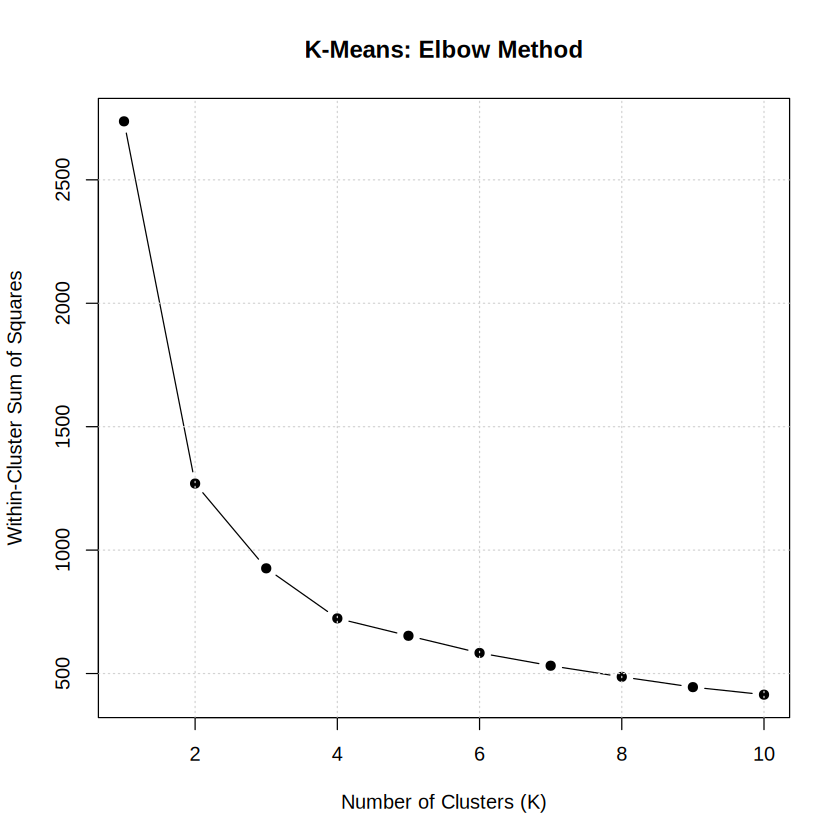


Best K according to Silhouette Method: 2 

Final K-Means Model:
K-means clustering with 3 clusters of sizes 95, 202, 95

Cluster means:
         mpg  cylinders displacement horsepower     weight acceleration
1 -1.1500879  1.4820530    1.4840150  1.4973795  1.3856117   -1.0646106
2  0.7628541 -0.8600086   -0.8099465 -0.6834302 -0.7941342    0.3630997
3 -0.4719807  0.3465969    0.2381871 -0.0441911  0.3029684    0.2925459
         year
1 -0.66597489
2  0.30791278
3  0.01125509

Clustering vector:
  [1] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 3 3 3 2 2 2 2 2 2 3 1 1 1 1 2 2 2 3 3 3 3 3
 [38] 1 1 1 1 1 1 1 3 2 3 3 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 2 1 1 1
 [75] 1 3 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 3 2 1 1 1 1 3 2 2 2 2
[112] 2 3 2 1 1 2 2 2 3 1 2 3 1 3 3 3 2 2 2 2 3 3 3 1 1 1 1 1 2 2 2 2 2 2 2 2 2
[149] 2 2 3 3 3 3 1 1 1 1 3 3 3 3 3 3 1 2 2 3 2 2 2 2 3 2 3 2 2 2 2 2 2 2 2 2 2
[186] 1 1 1 1 3 3 3 3 2 2 2 2 3 3 3 3 2 2 2 2 3 1 3 3 3 1 1 1 1 2 2 2 2 2 1 3 1
[223] 1 3 3 3 3 1 1

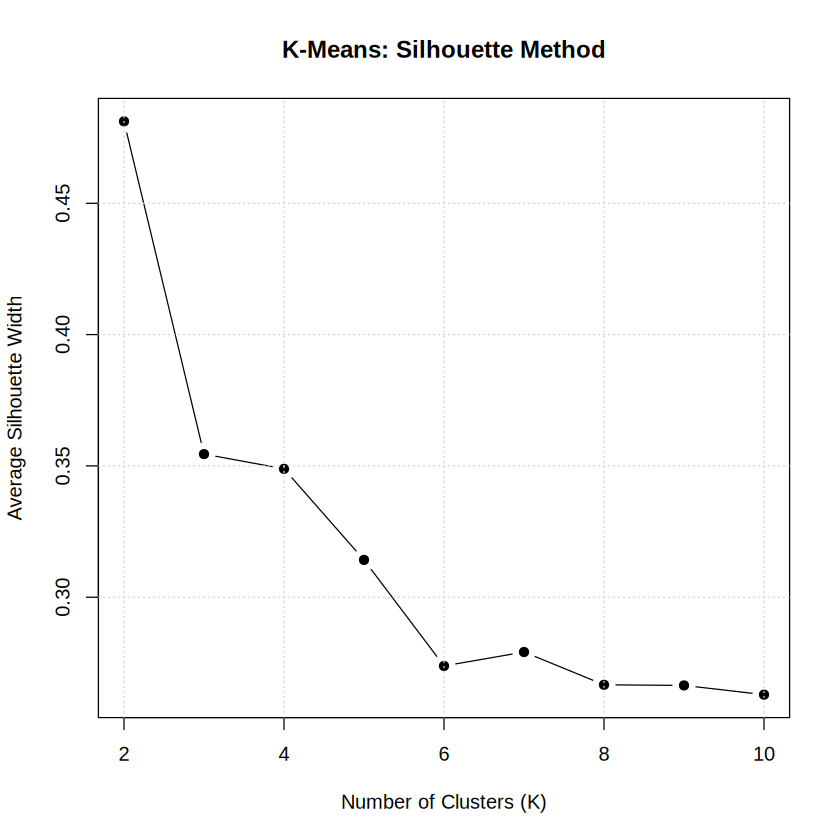


Average Silhouette Width of Final K-Means: 0.3544936 


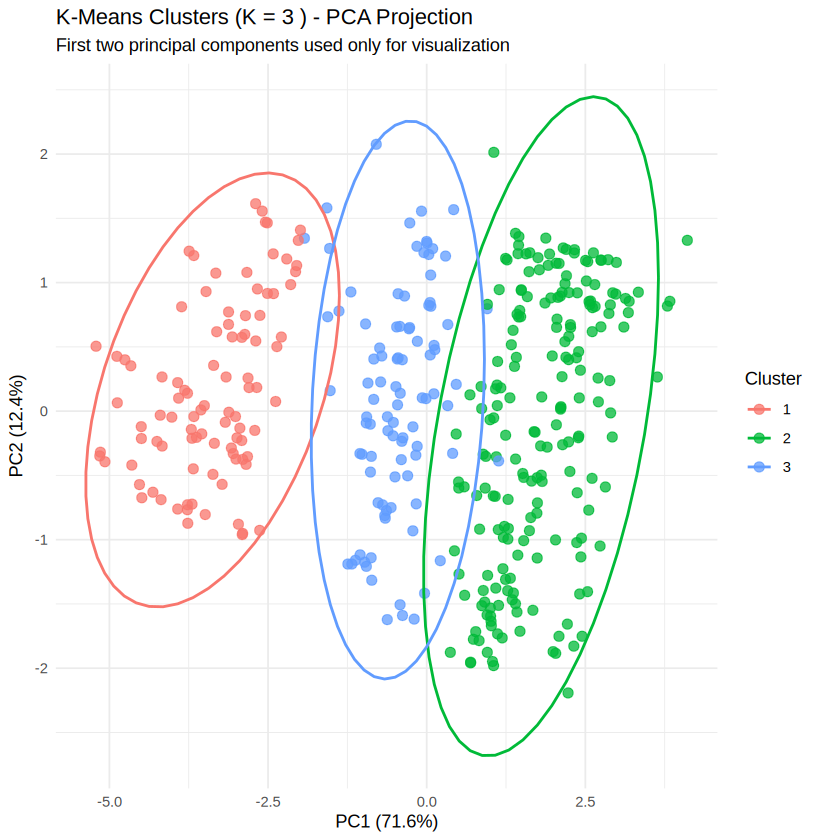


15. HIERARCHICAL CLUSTERING

First 20 Euclidean Distances:
 [1] 1.1071468 0.6471676 0.5860501 0.6212883 2.4747768 3.1443658 3.0444942
 [8] 3.1710692 2.2320571 1.5117880 1.7569776 1.4561078 3.0202921 3.6485807
[15] 2.4047171 2.3501007 2.6837305 3.9349966 5.3565403 4.0036331

Last 20 Euclidean Distances:
 [1] 1.5707582 4.4308416 0.7266050 2.3018060 2.4469785 0.6610814 3.7307340
 [8] 2.3068032 0.7445012 1.0257086 4.1156969 1.6902990 1.1428907 1.4891885
[15] 5.0426508 3.1324300 2.7314746 2.6246481 2.8785744 0.5004990

Total pairwise distances: 76636 

Ward's Method:

Call:
hclust(d = euclidean_distance, method = "ward.D2")

Cluster method   : ward.D2 
Distance         : euclidean 
Number of objects: 392 


Single Linkage:

Call:
hclust(d = euclidean_distance, method = "single")

Cluster method   : single 
Distance         : euclidean 
Number of objects: 392 


Complete Linkage:

Call:
hclust(d = euclidean_distance, method = "complete")

Cluster method   : complete 
Distance         : eucl

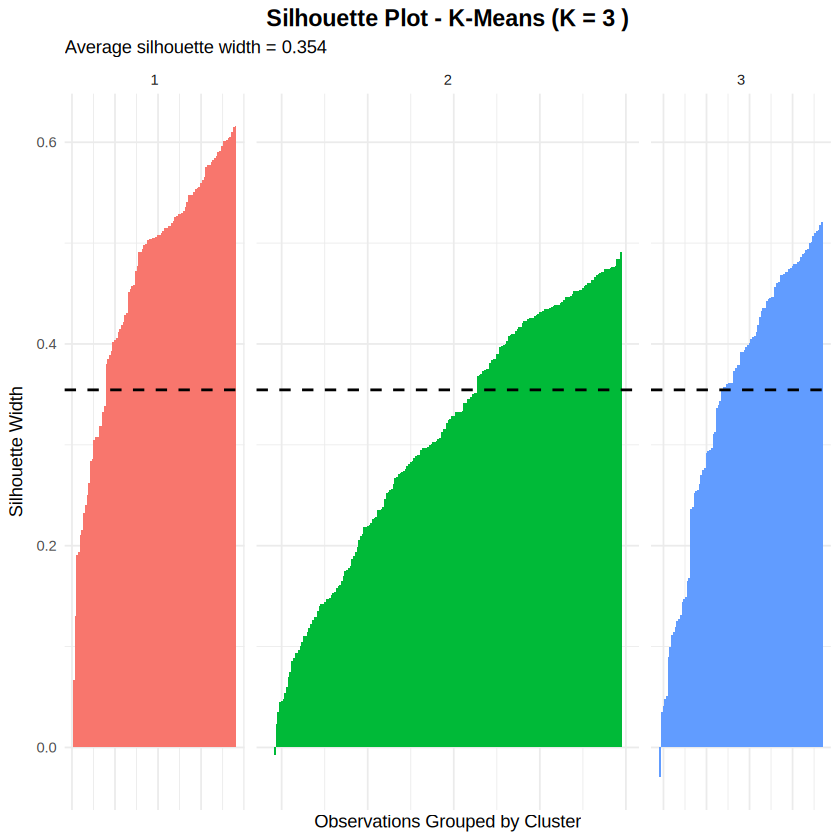

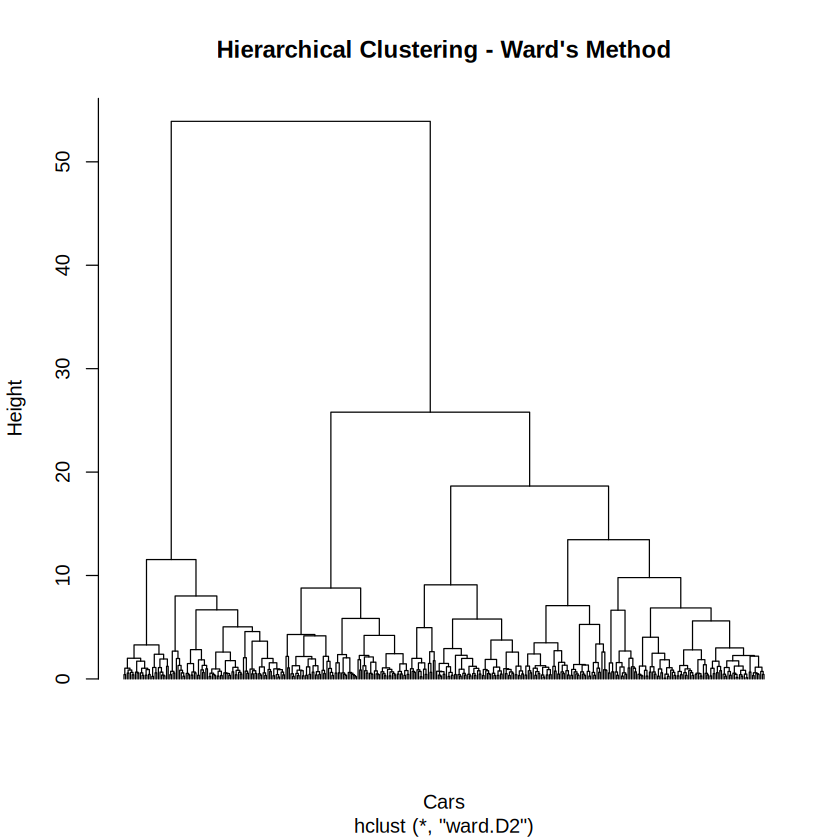

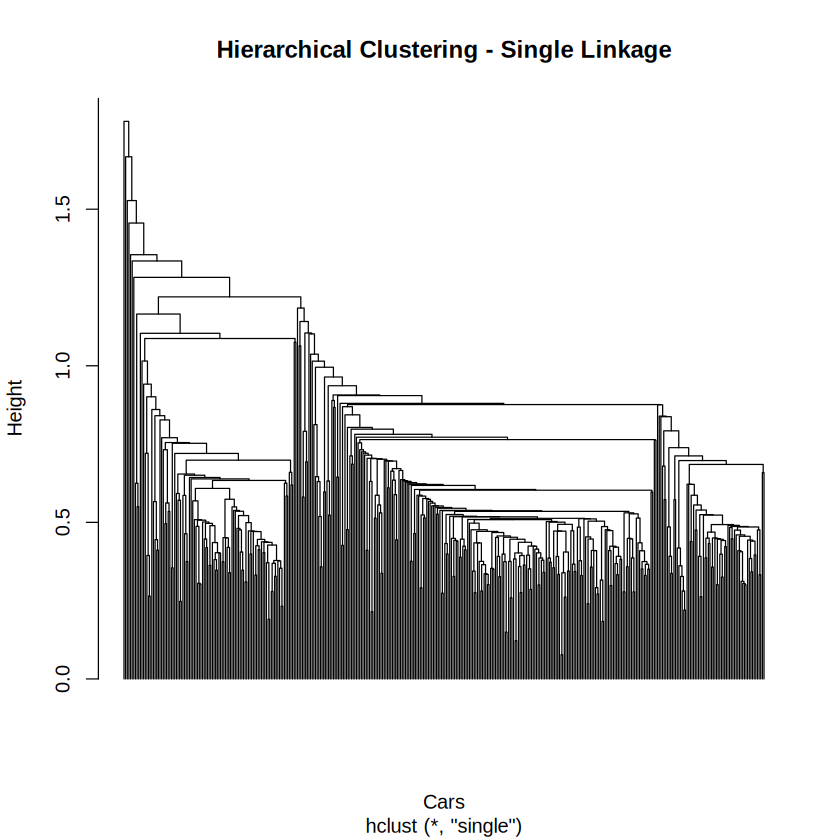

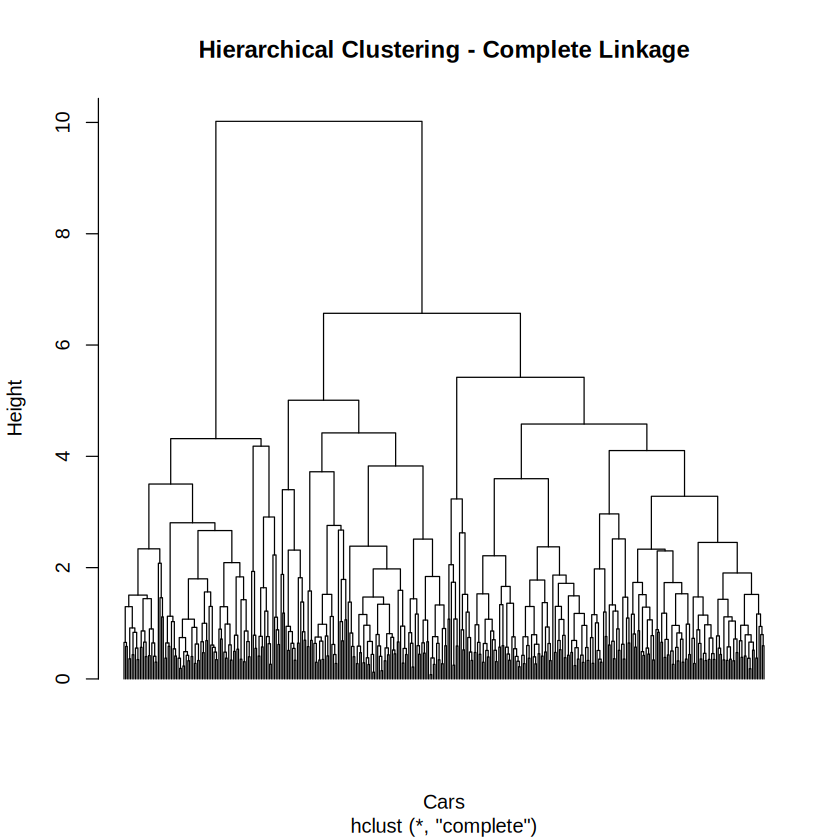


Number of Cars in Each Hierarchical Cluster:

  1   2   3 
 99 217  76 


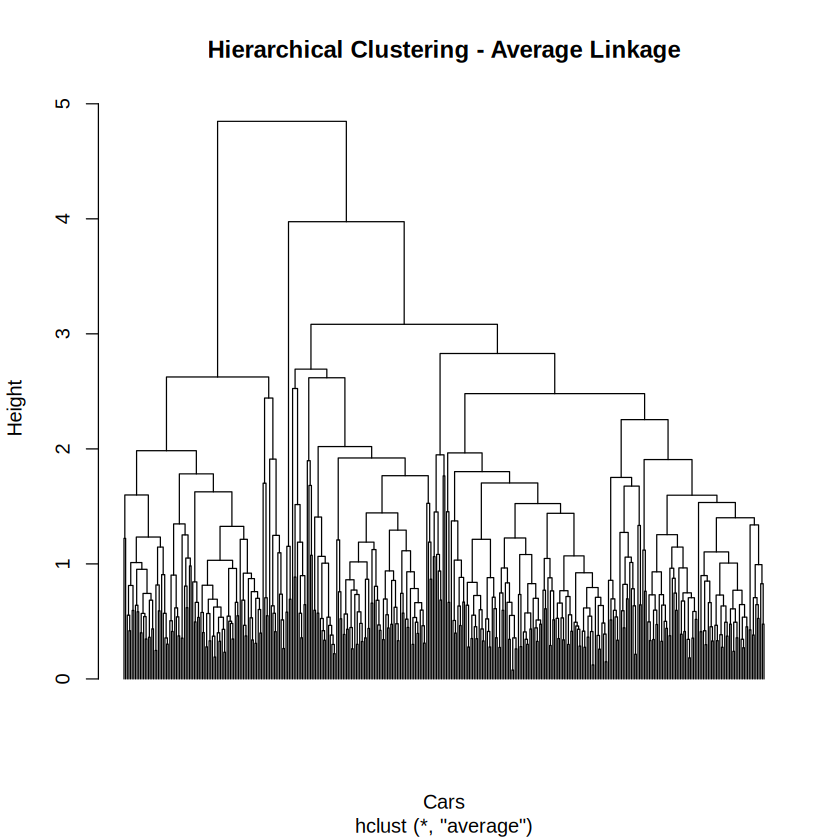


Hierarchical Cluster Profiles in Original Units:
  Cluster   mpg cylinders displacement horsepower  weight acceleration  year
1       1 14.65      8.00       346.63     160.35 4128.39        12.69 73.70
2       2 28.99      4.10       113.37      80.29 2349.08        16.44 77.22
3       3 19.06      6.11       227.53     100.71 3273.04        16.69 75.41

Hierarchical Cluster vs Actual Origin:
                    Origin
Hierarchical_Cluster USA Europe Japan
                   1  99      0     0
                   2  76     65    76
                   3  70      3     3

Row-wise Percentages:
                    Origin
Hierarchical_Cluster    USA Europe  Japan
                   1 100.00   0.00   0.00
                   2  35.02  29.95  35.02
                   3  92.11   3.95   3.95


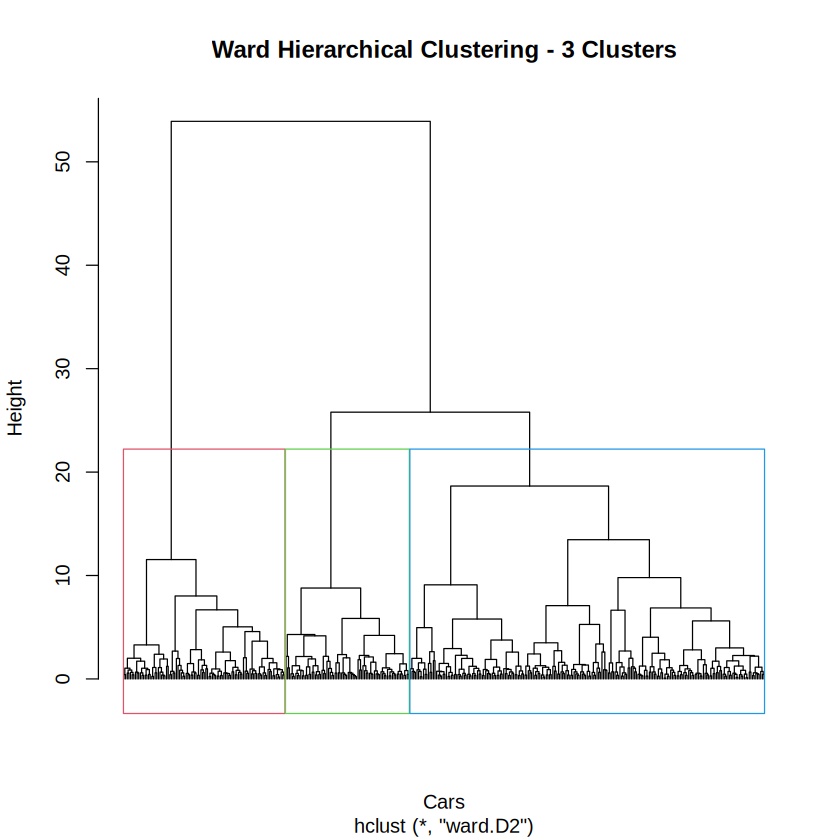


Average Silhouette Width of Ward Hierarchical Clustering: 0.3397756 

Average Silhouette Width of Ward Hierarchical Clustering: 0.3397756 


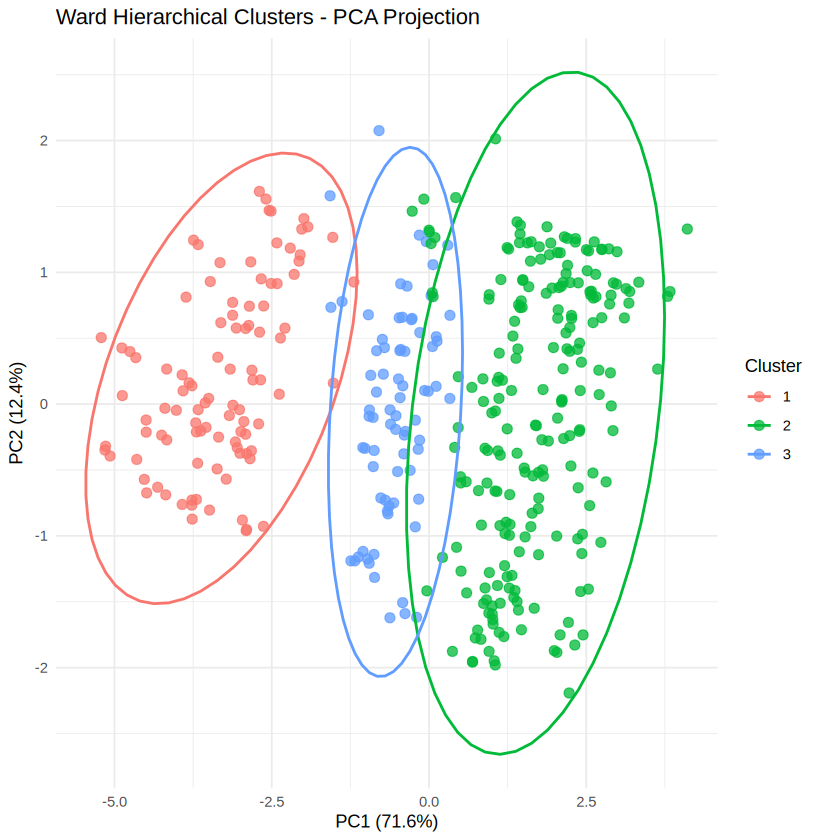


16. K-MEANS VS HIERARCHICAL CLUSTERING

K-Means vs Hierarchical Cluster Assignments:
      Hierarchical
KMeans   1   2   3
     1  95   0   0
     2   0 202   0
     3   4  15  76

Clustering Quality Comparison:
               Method Number_of_Clusters Average_Silhouette
1             K-Means                  3          0.3544936
2 Hierarchical - Ward                  3          0.3397756

17. FINAL DATA WITH CLUSTER ASSIGNMENTS

First 10 rows:
   mpg cylinders displacement horsepower weight acceleration year origin
1   18         8          307        130   3504         12.0   70    USA
2   15         8          350        165   3693         11.5   70    USA
3   18         8          318        150   3436         11.0   70    USA
4   16         8          304        150   3433         12.0   70    USA
5   17         8          302        140   3449         10.5   70    USA
6   15         8          429        198   4341         10.0   70    USA
7   14         8          454        22

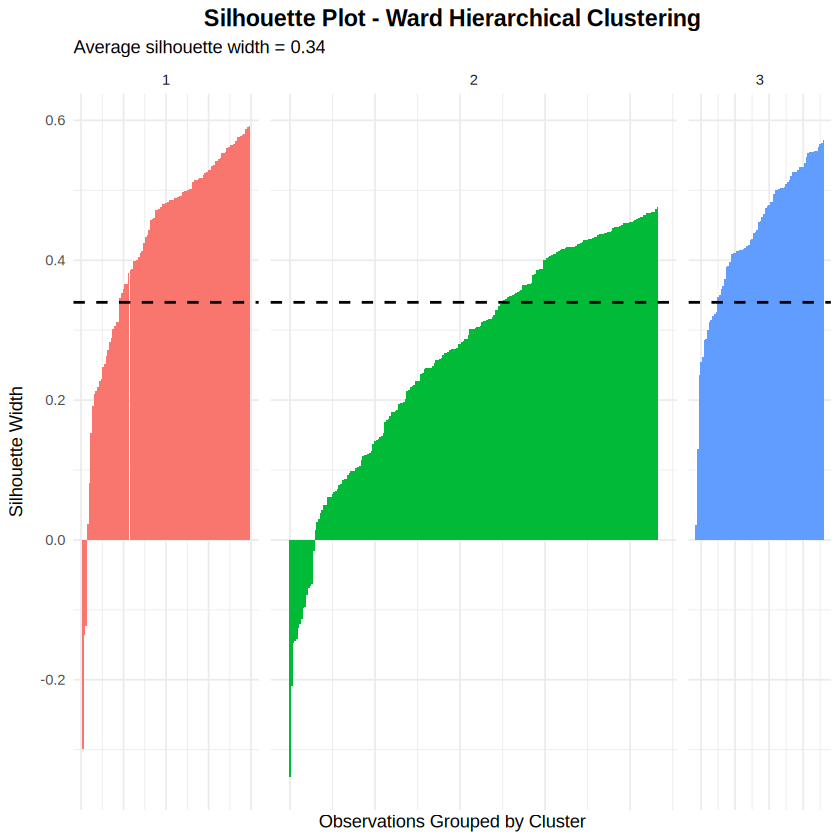

In [12]:


# ================================================================
# 13. PREPARING DATA FOR CLUSTERING
# ================================================================

cat("\n============================================================\n")
cat("13. DATA PREPARATION FOR CLUSTERING\n")
cat("============================================================\n")


cluster_data <- data.frame(

  mpg = df_phase2$mpg,

  cylinders =
    as.numeric(
      as.character(
        df_phase2$cylinders
      )
    ),

  displacement =
    df_phase2$displacement,

  horsepower =
    df_phase2$horsepower,

  weight =
    df_phase2$weight,

  acceleration =
    df_phase2$acceleration,

  year =
    df_phase2$year
)


# Check the data
cat("\nFeatures selected for clustering:\n")
print(names(cluster_data))

cat("\nFirst six clustering records:\n")
print(head(cluster_data))

cat("\nMissing values in clustering data:\n")
print(colSums(is.na(cluster_data)))


# Remove zero-variance columns, if any
non_zero_variance <- sapply(
  cluster_data,
  function(x)
    sd(x, na.rm = TRUE) > 0
)

cluster_data <- cluster_data[
  ,
  non_zero_variance,
  drop = FALSE
]


# ------------------------------------------------
# 13.1 Standardization
# ------------------------------------------------

scaled_cluster_data <- scale(
  cluster_data
)

cat("\nFirst six rows after Z-score standardization:\n")
print(
  head(scaled_cluster_data)
)


cat("\nMeans of standardized variables:\n")
print(
  round(
    colMeans(scaled_cluster_data),
    5
  )
)

cat("\nStandard deviations of standardized variables:\n")
print(
  round(
    apply(
      scaled_cluster_data,
      2,
      sd
    ),
    5
  )
)


# ================================================================
# 14. K-MEANS CLUSTERING
# ================================================================

cat("\n============================================================\n")
cat("14. K-MEANS CLUSTERING\n")
cat("============================================================\n")


# ------------------------------------------------
# 14.1 WCSS for K = 1 to 10
# ------------------------------------------------

set.seed(123)

wcss <- numeric(10)

for (k in 1:10) {

  km_temp <- kmeans(
    scaled_cluster_data,
    centers = k,
    nstart = 25
  )

  wcss[k] <-
    km_temp$tot.withinss
}

wcss_table <- data.frame(
  K = 1:10,
  WCSS = wcss
)

cat("\nWCSS Values:\n")
print(wcss_table)


# ------------------------------------------------
# 14.2 Elbow Plot
# ------------------------------------------------

plot(
  1:10,
  wcss,

  type = "b",
  pch = 19,

  xlab = "Number of Clusters (K)",
  ylab = "Within-Cluster Sum of Squares",

  main = "K-Means: Elbow Method"
)

grid()


# ------------------------------------------------
# 14.3 Automatic Approximate Elbow Detection
# ------------------------------------------------

x <- 1:10

x1 <- x[1]
y1 <- wcss[1]

x2 <- x[length(x)]
y2 <- wcss[length(wcss)]

distance_from_line <-
  abs(
    (y2 - y1) * x -
      (x2 - x1) * wcss +
      x2 * y1 -
      y2 * x1
  ) /
  sqrt(
    (y2 - y1)^2 +
      (x2 - x1)^2
  )

elbow_k <- which.max(
  distance_from_line
)

cat(
  "\nApproximate optimal K from Elbow Method:",
  elbow_k,
  "\n"
)


# ------------------------------------------------
# 14.4 Silhouette Method for K = 2 to 10
# ------------------------------------------------

silhouette_scores <- numeric(9)

for (k in 2:10) {

  set.seed(123)

  km_temp <- kmeans(
    scaled_cluster_data,
    centers = k,
    nstart = 25
  )

  sil_temp <- silhouette(
    km_temp$cluster,
    dist(scaled_cluster_data)
  )

  silhouette_scores[k - 1] <-
    mean(
      sil_temp[, 3]
    )
}

silhouette_table <- data.frame(
  K = 2:10,
  Average_Silhouette =
    silhouette_scores
)

cat("\nAverage Silhouette Widths:\n")
print(silhouette_table)


plot(
  2:10,
  silhouette_scores,

  type = "b",
  pch = 19,

  xlab = "Number of Clusters (K)",
  ylab = "Average Silhouette Width",

  main = "K-Means: Silhouette Method"
)

grid()


best_silhouette_k <-
  which.max(
    silhouette_scores
  ) + 1

cat(
  "\nBest K according to Silhouette Method:",
  best_silhouette_k,
  "\n"
)


# ------------------------------------------------
# 14.5 Final K-Means
# ------------------------------------------------
# Use the elbow result so this follows the same methodology
# used in your previous clustering assignment.

optimal_k <- elbow_k

set.seed(123)

final_kmeans <- kmeans(
  scaled_cluster_data,
  centers = optimal_k,
  nstart = 50,
  iter.max = 100
)

cat("\nFinal K-Means Model:\n")
print(final_kmeans)


# ------------------------------------------------
# 14.6 Cluster Sizes
# ------------------------------------------------

cat("\nNumber of Cars in Each K-Means Cluster:\n")
print(
  table(
    final_kmeans$cluster
  )
)


# ------------------------------------------------
# 14.7 Standardized Cluster Centers
# ------------------------------------------------

cat("\nStandardized Cluster Centers:\n")
print(
  round(
    final_kmeans$centers,
    3
  )
)


# ------------------------------------------------
# 14.8 Cluster Centers in ORIGINAL Units
# ------------------------------------------------

kmeans_centers_original <-
  aggregate(
    cluster_data,

    by = list(
      Cluster =
        final_kmeans$cluster
    ),

    FUN = mean
  )

cat("\nK-Means Cluster Profiles in Original Units:\n")
print(
  round(
    kmeans_centers_original,
    2
  )
)


# Add K-Means cluster assignment to the Phase 2 dataframe
df_phase2$KMeans_Cluster <-
  factor(
    final_kmeans$cluster
  )


# ------------------------------------------------
# 14.9 K-Means Cluster vs Origin
# ------------------------------------------------

cat("\nK-Means Cluster vs Actual Origin:\n")

kmeans_origin_table <- table(
  KMeans_Cluster =
    df_phase2$KMeans_Cluster,

  Origin =
    df_phase2$origin
)

print(kmeans_origin_table)

cat("\nRow-wise Percentages:\n")

print(
  round(
    prop.table(
      kmeans_origin_table,
      margin = 1
    ) * 100,
    2
  )
)


# ------------------------------------------------
# 14.10 PCA for Clear Cluster Visualization
# ------------------------------------------------
# A PCA plot is clearer than plotting MPG against Cylinders,
# because cylinders only has a few discrete values.

cluster_pca <- prcomp(
  scaled_cluster_data,
  center = FALSE,
  scale. = FALSE
)

cat("\nPCA Variance Explained:\n")

pca_variance <-
  cluster_pca$sdev^2 /
  sum(cluster_pca$sdev^2)

print(
  round(
    pca_variance * 100,
    2
  )
)


pca_plot_data <- data.frame(

  PC1 =
    cluster_pca$x[, 1],

  PC2 =
    cluster_pca$x[, 2],

  Cluster =
    factor(
      final_kmeans$cluster
    ),

  Origin =
    df_phase2$origin
)


p21 <- ggplot(
  pca_plot_data,
  aes(
    x = PC1,
    y = PC2,
    color = Cluster
  )
) +
  geom_point(
    alpha = 0.75,
    size = 2.5
  ) +
  stat_ellipse(
    type = "norm",
    linewidth = 0.8
  ) +
  theme_minimal() +
  labs(
    title = paste(
      "K-Means Clusters (K =",
      optimal_k,
      ") - PCA Projection"
    ),
    subtitle =
      "First two principal components used only for visualization",
    x = paste0(
      "PC1 (",
      round(pca_variance[1] * 100, 1),
      "%)"
    ),
    y = paste0(
      "PC2 (",
      round(pca_variance[2] * 100, 1),
      "%)"
    )
  )

print(p21)


# ------------------------------------------------
# 14.11 K-Means Silhouette Plot
# ------------------------------------------------

final_kmeans_silhouette <- silhouette(
  final_kmeans$cluster,
  dist(scaled_cluster_data)
)

cat(
  "\nAverage Silhouette Width of Final K-Means:",
  mean(final_kmeans_silhouette[, 3]),
  "\n"
)

# Convert K-Means silhouette result to dataframe
kmeans_sil_df <- as.data.frame(final_kmeans_silhouette)

kmeans_sil_df$Observation <- 1:nrow(kmeans_sil_df)
kmeans_sil_df$Cluster <- factor(kmeans_sil_df$cluster)

kmeans_sil_df <- kmeans_sil_df %>%
  arrange(Cluster, sil_width) %>%
  mutate(
    Observation = row_number()
  )

p_kmeans_sil <- ggplot(
  kmeans_sil_df,
  aes(
    x = Observation,
    y = sil_width,
    fill = Cluster
  )
) +
  geom_col(
    width = 1
  ) +
  geom_hline(
    yintercept = mean(final_kmeans_silhouette[, 3]),
    linetype = "dashed",
    linewidth = 0.8
  ) +
  facet_grid(
    . ~ Cluster,
    scales = "free_x",
    space = "free_x"
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.spacing = unit(0.5, "lines"),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    plot.title = element_text(
      hjust = 0.5,
      face = "bold",
      size = 14
    )
  ) +
  labs(
    title = paste(
      "Silhouette Plot - K-Means (K =",
      optimal_k,
      ")"
    ),
    subtitle = paste(
      "Average silhouette width =",
      round(mean(final_kmeans_silhouette[, 3]), 3)
    ),
    x = "Observations Grouped by Cluster",
    y = "Silhouette Width"
  )

print(p_kmeans_sil)

# ================================================================
# 15. HIERARCHICAL CLUSTERING
# ================================================================

cat("\n============================================================\n")
cat("15. HIERARCHICAL CLUSTERING\n")
cat("============================================================\n")


# ------------------------------------------------
# 15.1 Euclidean Distance
# ------------------------------------------------

euclidean_distance <- dist(
  scaled_cluster_data,
  method = "euclidean"
)

cat("\nFirst 20 Euclidean Distances:\n")
print(
  head(
    as.vector(euclidean_distance),
    20
  )
)

cat("\nLast 20 Euclidean Distances:\n")
print(
  tail(
    as.vector(euclidean_distance),
    20
  )
)

cat(
  "\nTotal pairwise distances:",
  length(euclidean_distance),
  "\n"
)


# ------------------------------------------------
# 15.2 Hierarchical Clustering using
# Different Linkage Methods
# ------------------------------------------------

hc_ward <- hclust(
  euclidean_distance,
  method = "ward.D2"
)

hc_single <- hclust(
  euclidean_distance,
  method = "single"
)

hc_complete <- hclust(
  euclidean_distance,
  method = "complete"
)

hc_average <- hclust(
  euclidean_distance,
  method = "average"
)


cat("\nWard's Method:\n")
print(hc_ward)

cat("\nSingle Linkage:\n")
print(hc_single)

cat("\nComplete Linkage:\n")
print(hc_complete)

cat("\nAverage Linkage:\n")
print(hc_average)


# ------------------------------------------------
# 15.3 Ward Dendrogram
# ------------------------------------------------
# Plotted individually so the dendrogram is large and readable.

plot(
  hc_ward,

  labels = FALSE,
  hang = -1,

  main = "Hierarchical Clustering - Ward's Method",
  xlab = "Cars",
  ylab = "Height"
)


# ------------------------------------------------
# 15.4 Single Linkage Dendrogram
# ------------------------------------------------

plot(
  hc_single,

  labels = FALSE,
  hang = -1,

  main = "Hierarchical Clustering - Single Linkage",
  xlab = "Cars",
  ylab = "Height"
)


# ------------------------------------------------
# 15.5 Complete Linkage Dendrogram
# ------------------------------------------------

plot(
  hc_complete,

  labels = FALSE,
  hang = -1,

  main = "Hierarchical Clustering - Complete Linkage",
  xlab = "Cars",
  ylab = "Height"
)


# ------------------------------------------------
# 15.6 Average Linkage Dendrogram
# ------------------------------------------------

plot(
  hc_average,

  labels = FALSE,
  hang = -1,

  main = "Hierarchical Clustering - Average Linkage",
  xlab = "Cars",
  ylab = "Height"
)


# ------------------------------------------------
# 15.7 Cut Ward Dendrogram into same number
# of clusters selected for K-Means
# ------------------------------------------------

hierarchical_clusters <- cutree(
  hc_ward,
  k = optimal_k
)

df_phase2$Hierarchical_Cluster <-
  factor(
    hierarchical_clusters
  )


cat("\nNumber of Cars in Each Hierarchical Cluster:\n")
print(
  table(
    df_phase2$Hierarchical_Cluster
  )
)


# ------------------------------------------------
# 15.8 Ward Dendrogram with Cluster Rectangles
# ------------------------------------------------

plot(
  hc_ward,

  labels = FALSE,
  hang = -1,

  main = paste(
    "Ward Hierarchical Clustering -",
    optimal_k,
    "Clusters"
  ),

  xlab = "Cars",
  ylab = "Height"
)

rect.hclust(
  hc_ward,
  k = optimal_k,
  border = 2:(optimal_k + 1)
)


# ------------------------------------------------
# 15.9 Hierarchical Cluster Profiles
# ------------------------------------------------

hierarchical_centers_original <-
  aggregate(
    cluster_data,

    by = list(
      Cluster =
        hierarchical_clusters
    ),

    FUN = mean
  )

cat("\nHierarchical Cluster Profiles in Original Units:\n")
print(
  round(
    hierarchical_centers_original,
    2
  )
)


# ------------------------------------------------
# 15.10 Hierarchical Cluster vs Origin
# ------------------------------------------------

hierarchical_origin_table <- table(
  Hierarchical_Cluster =
    df_phase2$Hierarchical_Cluster,

  Origin =
    df_phase2$origin
)

cat("\nHierarchical Cluster vs Actual Origin:\n")
print(
  hierarchical_origin_table
)

cat("\nRow-wise Percentages:\n")
print(
  round(
    prop.table(
      hierarchical_origin_table,
      margin = 1
    ) * 100,
    2
  )
)


# ------------------------------------------------
# 15.11 PCA Visualization of Hierarchical Clusters
# ------------------------------------------------

hierarchical_pca_data <- data.frame(

  PC1 =
    cluster_pca$x[, 1],

  PC2 =
    cluster_pca$x[, 2],

  Cluster =
    factor(
      hierarchical_clusters
    )
)


p22 <- ggplot(
  hierarchical_pca_data,
  aes(
    x = PC1,
    y = PC2,
    color = Cluster
  )
) +
  geom_point(
    alpha = 0.75,
    size = 2.5
  ) +
  stat_ellipse(
    type = "norm",
    linewidth = 0.8
  ) +
  theme_minimal() +
  labs(
    title =
      "Ward Hierarchical Clusters - PCA Projection",

    x = paste0(
      "PC1 (",
      round(pca_variance[1] * 100, 1),
      "%)"
    ),

    y = paste0(
      "PC2 (",
      round(pca_variance[2] * 100, 1),
      "%)"
    )
  )

print(p22)


# ------------------------------------------------
# 15.12 Hierarchical Silhouette Analysis
# ------------------------------------------------

hierarchical_silhouette <- silhouette(
  hierarchical_clusters,
  euclidean_distance
)

cat(
  "\nAverage Silhouette Width of Ward Hierarchical Clustering:",
  mean(hierarchical_silhouette[, 3]),
  "\n"
)

# ------------------------------------------------
# 15.12 Hierarchical Silhouette Analysis
# ------------------------------------------------

hierarchical_silhouette <- silhouette(
  hierarchical_clusters,
  euclidean_distance
)

cat(
  "\nAverage Silhouette Width of Ward Hierarchical Clustering:",
  mean(hierarchical_silhouette[, 3]),
  "\n"
)

# Convert silhouette result to dataframe
hier_sil_df <- as.data.frame(hierarchical_silhouette)

hier_sil_df$Observation <- 1:nrow(hier_sil_df)
hier_sil_df$Cluster <- factor(hier_sil_df$cluster)

# Arrange observations by cluster and silhouette width
hier_sil_df <- hier_sil_df %>%
  arrange(Cluster, sil_width) %>%
  mutate(
    Observation = row_number()
  )

# Plot using ggplot2
p_hier_sil <- ggplot(
  hier_sil_df,
  aes(
    x = Observation,
    y = sil_width,
    fill = Cluster
  )
) +
  geom_col(
    width = 1
  ) +
  geom_hline(
    yintercept = mean(hierarchical_silhouette[, 3]),
    linetype = "dashed",
    linewidth = 0.8
  ) +
  facet_grid(
    . ~ Cluster,
    scales = "free_x",
    space = "free_x"
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.spacing = unit(0.5, "lines"),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    plot.title = element_text(
      hjust = 0.5,
      face = "bold",
      size = 14
    )
  ) +
  labs(
    title = "Silhouette Plot - Ward Hierarchical Clustering",
    subtitle = paste(
      "Average silhouette width =",
      round(mean(hierarchical_silhouette[, 3]), 3)
    ),
    x = "Observations Grouped by Cluster",
    y = "Silhouette Width"
  )

print(p_hier_sil)


# ================================================================
# 16. COMPARISON OF K-MEANS AND HIERARCHICAL CLUSTERING
# ================================================================

cat("\n============================================================\n")
cat("16. K-MEANS VS HIERARCHICAL CLUSTERING\n")
cat("============================================================\n")


# ------------------------------------------------
# 16.1 Cluster Assignment Cross-Table
# ------------------------------------------------

cluster_comparison <- table(

  KMeans =
    final_kmeans$cluster,

  Hierarchical =
    hierarchical_clusters
)

cat("\nK-Means vs Hierarchical Cluster Assignments:\n")
print(cluster_comparison)


# ------------------------------------------------
# 16.2 Compare Average Silhouette Scores
# ------------------------------------------------

clustering_quality <- data.frame(

  Method = c(
    "K-Means",
    "Hierarchical - Ward"
  ),

  Number_of_Clusters =
    c(
      optimal_k,
      optimal_k
    ),

  Average_Silhouette =
    c(
      mean(final_kmeans_silhouette[, 3]),
      mean(hierarchical_silhouette[, 3])
    )
)

cat("\nClustering Quality Comparison:\n")
print(clustering_quality)


# ================================================================
# 17. FINAL CLUSTERED DATASET
# ================================================================

cat("\n============================================================\n")
cat("17. FINAL DATA WITH CLUSTER ASSIGNMENTS\n")
cat("============================================================\n")

cat("\nFirst 10 rows:\n")

print(
  head(
    df_phase2,
    10
  )
)


cat("\nFinal Dataset Dimensions:\n")
print(
  dim(df_phase2)
)
